Reinforcement Learning Programming Assignment

## MinAtar: Learning to Play Atari-Style Games

This assignment asks you to design, implement, and analyze reinforcement learning algorithms on MinAtar, a set of simplified Atari-style environments. MinAtar provides the visual complexity of Atari games at reduced computational cost: observations are 10×10 pixel grids with a small number of channels, and episodes run faster than their full-scale counterparts.

You will work primarily with **Breakout**, then test whether your methods transfer to other MinAtar games.

### Objectives

By the end of this assignment, you should be able to:

- Analyze an RL environment: state space, action space, reward structure, and episode dynamics
- Select and justify appropriate state representations for learning
- Implement at least two RL algorithms: one classical, one using neural networks
- Interpret learned policies through visualization and quantitative analysis
- Diagnose training issues and apply techniques to address them
- Evaluate generalization across different environments

### Deliverables

Submit a single Jupyter notebook that serves as both your implementation and your report. Your notebook should:

1. **Run end-to-end** without errors
2. **Document your approach** with clear explanations in markdown cells
3. **Present results** with well-labeled figures and tables
4. **Analyze findings** with interpretation of what works, what fails, and why

### Rules

- **Implement RL algorithms yourself.** Do not use RL libraries (stable-baselines, RLlib, CleanRL, etc.)
- **Standard libraries are allowed.** PyTorch, NumPy, scikit-learn, matplotlib, and similar tools are permitted.
- **Cite your sources.** If you adapt an algorithm from a paper or other resource, reference it.

---
## Part 0: Environment and Baselines

The code below sets up the MinAtar Breakout environment and provides two baseline policies for comparison:

- **Random policy**: selects actions uniformly at random
- **Heuristic policy**: moves the paddle toward the ball's horizontal position


In [1]:
import numpy as np
import gymnasium as gym
from minatar import Environment
from minatar.gym import register_envs
import random


if "MinAtar/Breakout-v1" not in gym.envs.registry:
    register_envs()

In [ ]:
import pandas as pd
import torch
import torch.nn.functional as F

For reproductibility: 

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
  
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42

In [4]:
def random_policy(observation, num_actions):
    return np.random.randint(num_actions)

In [5]:
def breakout_heuristic_policy(observation, num_actions):
    paddle_channel = observation[:, :, 0]
    ball_channel = observation[:, :, 1]

    paddle_pos = np.where(paddle_channel == 1) #pixels qui valent 1 sur paddle channel = la raquette
    ball_pos = np.where(ball_channel == 1) #pixels qui valent 1 sur ball channel = la balle

    if len(paddle_pos[1]) == 0 or len(ball_pos[1]) == 0:
        return 0

    paddle_x = paddle_pos[1].mean() #centre de la raquette
    ball_x = ball_pos[1].mean() #centre de la balle

  #si la balle est à gauche de la raquette, la raquette va à gauche
    if ball_x < paddle_x:
        return 1 #aller à gauche
  #si la balle est à droite de la raquette, la raquette va à droite
    elif ball_x > paddle_x:
        return 2 #aller à droite
    else:
        return 0 #ne pas bouger

In [6]:

def run_episode(env, policy_fn,SEED = None):  #input = environnement et une des deux policies ci dessus
    observation, info = env.reset(seed = SEED)
    num_actions = env.action_space.n

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated): #tant que l'episode dure:
        action = policy_fn(observation, num_actions) #on joue la policy et on choisit une action
        observation, reward, terminated, truncated, info = env.step(action) #on voit la réaction de l'environnement
        total_reward += reward
        steps += 1 #durée de l'épisode

    return total_reward, steps #récompense totale et durée de l'épisode


def evaluate_policy(env, policy_fn, num_episodes=100):
    rewards = []
    steps_list = []
    SEED = 42

    for episode in range(num_episodes):  #on évalue la policy sur 100 épisodes
        #pour chaque épisode on regarde la récompense totale et la durée de l'épisode (steps)
        total_reward, steps = run_episode(env, policy_fn,SEED + episode)

        rewards.append(total_reward)
        steps_list.append(steps)

    return np.array(rewards), np.array(steps_list)

In [7]:
env = gym.make("MinAtar/Breakout-v1")
env.action_space.seed(SEED)
env.reset()

print(f"Observation shape: {env.observation_space.shape}")
print(f"Number of actions: {env.action_space.n}")

Observation shape: (10, 10, 4)
Number of actions: 3


In [11]:
num_episodes = 1000
set_seed(SEED)

random_rewards, random_steps = evaluate_policy(env, random_policy, num_episodes)
print(f"Random Policy:")
print(f"  Reward: {random_rewards.mean():.2f} +/- {random_rewards.std():.2f}")
print(f"  Steps:  {random_steps.mean():.2f} +/- {random_steps.std():.2f}")

heuristic_rewards, heuristic_steps = evaluate_policy(env, breakout_heuristic_policy, num_episodes)
print(f"\nHeuristic Policy:")
print(f"  Reward: {heuristic_rewards.mean():.2f} +/- {heuristic_rewards.std():.2f}")
print(f"  Steps:  {heuristic_steps.mean():.2f} +/- {heuristic_steps.std():.2f}")

Random Policy:
  Reward: 0.39 +/- 0.64
  Steps:  9.94 +/- 6.65

Heuristic Policy:
  Reward: 8.44 +/- 9.06
  Steps:  98.86 +/- 105.15


In [12]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML


def render_frame(env):
    frame = env.render()
    return (frame * 255).astype(np.uint8)


def run_episode_with_frames(env, policy_fn,seed=42, max_steps=500):
    observation, info = env.reset(seed = seed)
    env.action_space.seed(seed)
    num_actions = env.action_space.n
    frames = [render_frame(env)]

    total_reward = 0
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(observation, num_actions)
        observation, reward, terminated, truncated, info = env.step(action)
        frames.append(render_frame(env))
        total_reward += reward
        steps += 1

    return frames, total_reward, steps


def animate_episode(frames, interval=50):
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis("off")
    img = ax.imshow(frames[0], interpolation="nearest")

    def update(frame):
        img.set_array(frame)
        return [img]

    anim = animation.FuncAnimation(
        fig, update, frames=frames, interval=interval, blit=True
    )
    plt.close(fig)
    return anim


env_visual = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array", disable_env_checker=True)
env.action_space.seed(SEED)
env_visual.reset()

frames, reward, steps = run_episode_with_frames(env_visual, breakout_heuristic_policy)
print(f"Episode: Reward = {reward}, Steps = {steps}")

anim = animate_episode(frames, interval=100)
HTML(anim.to_jshtml())

Episode: Reward = 2, Steps = 26


---

## Part 1: Environment Analysis [5 marks]

Before designing learning algorithms, you must understand the environment.

### Questions to Address

1. **State space**: What is the shape of the observations? What does each channel represent? How many unique states are theoretically possible?

Each observation is a tridimensional tensor taking boolean values, of dimension (10,10,4).
- The first channel of an observation (observation[:, :, 0]), corresponds to the position of the paddle. It is a 10 x 10 grid of 100 points, with one point equal to one representing the position of the paddle on the grid, and the 99 remaining pixels are equal to zero;
- The second channel of an observation ((observation[:, :, 1]) corresponds to the position of the ball. It is a 10 x 10 grid, with one point equal to one representing the position of the ball on the grid, and the 99 remaining pixels are equal to zero;
- The third channel of an observation ((observation[:, :, 2]) corresponds to the position of the ball trail. It is a 10 x 10 grid, with one point equal to one representing the position of the ball at the previous time step (remaining pixels are 0). It brings information on the speed of the ball when comparing the position of the ball and the position of the trail;
- The fourth channel of an observation ((observation[:, :, 3]) corresponds to the position of remaining bricks. It is also a 10 x 10 grid;

The tensor contains $10 \times 10 \times 4 = 400$ boolean variables so theoretically, there are $2^{400}$ possible states. However in practice the number of possible reachable states is much smaller if we take into account the game dynamics: for instance, the ball trail must be adjactent to the ball, and the paddle must remain at the bottom of the frame.

2. **Action space**: What actions are available? How do they affect the game state?

There are 3 actions, labeled $0,1,2$:
- action 0 is not moving the paddle,
- action 1 is moving the paddle to the left,
- action 2 is moving the paddle to the right.

The actions affect the position of the ball, i.e. they affect the first channel of the observations. The actions also indirectly affect the way the ball bounce against the paddle and the bricks, so it also indirectly affects the other channels.

3. **Reward structure**: When and how frequently does the agent receive rewards? What is the typical range of episode returns?

At each time step, the agent receives a reward of 1 if a brick is destroyed, and of zero otherwise. So the reward structure is sparse.

The range of rewards is contained between 0 and 30 (total number of bricks) and it depends on the policy:
- for the random policy, the average reward (over 1000 episodes) is of 0.39 and the standard deviation if of 0.64. 
- for the heuristic policy, the average reward is of 8.44 and the standard deviation if of 9.06.


4. **Episode dynamics**: What causes an episode to terminate? What is the distribution of episode lengths under the random and heuristic policies?

An episode terminates when the ball touches the lower part of the grid, without being intercepted by the paddle.

From the code above, we see that:
- the average length of an episode of the random policy is 9.94 steps and that the standard deviation is of 6.65 (over 1000 episodes),
- the average length of an episode of the heuristic policy is 98.86 steps and that the standard deviation is of 105.15.

5. **Stochasticity**: Is the environment deterministic or stochastic? If stochastic, what are the sources of randomness?

The environment is stochastic because of sticky actions: at each step $t$, there is a probability $p=0.1$ that the action $a_t$ played is not the one chosen by the agent at time $t$ but is the previous action $a_{t-1}$.  


**Visualisation:**

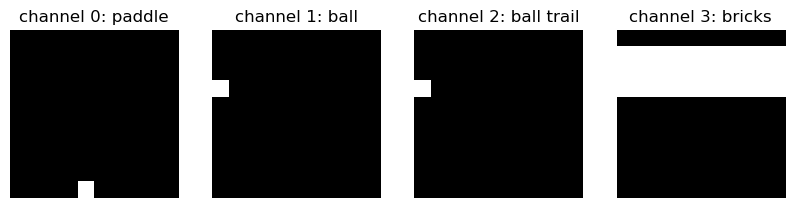

In [33]:
#visualizing observation channels
obs, info = env.reset()
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
titles = ['channel 0: paddle', 'channel 1: ball', 'channel 2: ball trail', 'channel 3: bricks']

for i in range(4):
    axes[i].imshow(obs[:, :, i], cmap='gray')
    axes[i].set_title(titles[i])
    axes[i].axis('off')
plt.show()

**Distribution of rewards and episode length for the random policy over 1000 episodes**

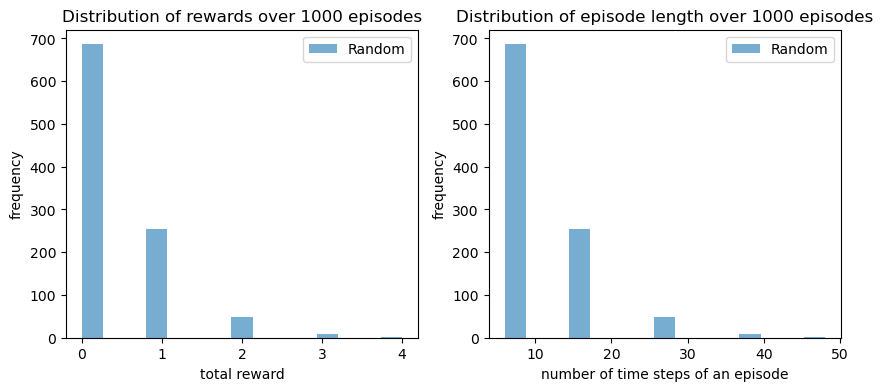

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(random_rewards, bins=15, alpha=0.6, label='Random')
ax1.set_title('Distribution of rewards over 1000 episodes')
ax1.set_xlabel('total reward')
ax1.set_ylabel('frequency')
ax1.legend()

ax2.hist(random_steps, bins=15, alpha=0.6, label='Random')

ax2.set_title('Distribution of episode length over 1000 episodes')
ax2.set_xlabel('number of time steps of an episode')
ax2.set_ylabel('frequency')
ax2.legend()

plt.show()

**Distribution of rewards and episode length for the heuristic policy over 1000 episodes**

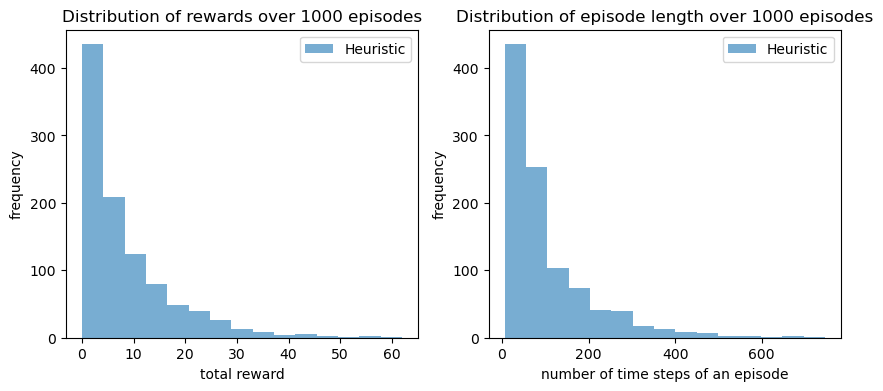

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(heuristic_rewards, bins=15, alpha=0.6, label='Heuristic')
ax1.set_title('Distribution of rewards over 1000 episodes')
ax1.set_xlabel('total reward')
ax1.set_ylabel('frequency')
ax1.legend()

ax2.hist(heuristic_steps, bins=15, alpha=0.6, label='Heuristic')

ax2.set_title('Distribution of episode length over 1000 episodes')
ax2.set_xlabel('number of time steps of an episode')
ax2.set_ylabel('frequency')
ax2.legend()

plt.show()

---

## Part 2: A Classical RL Method [8 marks]

Implement a reinforcement learning algorithm that does not use neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm given your analysis of the state space
- Choose an appropriate state representation
- Justify your choices based on the environment properties you identified in Part 1

### Questions to Address

1. **State representation**: How do you represent the state? Why is this representation appropriate for your chosen algorithm?

As mentioned in part 1, there are theoretically $2^{400}$ possible states, so it is not possible to maintain a Q-table for all these states. To solve this problem, I will represent the state with a few features to have a discrete, finite state space with a reasonable size. I'll use the following features to represent each state: 
- the position of the paddle, represented by a horizontal coordinate $paddle_x$ at the bottom of the grid, taking values in $\{0,1,2,\dots,9\}$, 
- the position of the ball, represented by a pair of spatial coordinates $(ball_x,ball_y)$ taking values in $\{0,1,2,\dots,9\} \times \{0,1,2,\dots,9\}$. The first coordinate $ball_x$ represents the position of the ball on the x-axis of the grid, the second coordinates $ball_y$ represent the position on the y-axis of the grid,
- the velocity of the ball, represented by a pair of coordinates $(v_x,v_y)$ taking values in $\{-1,0,1\} \times \{-1,0,1\}$. It is the difference between the current position of the ball and its position at the previous step (this is the current position of the ball trail). It is computed as:
    - $v_x = ball_x - trail_x$, where $trail_x$ is the position of the ball trail on the x-axis of the grid.
    - $v_y = ball_y - trail_y$, where $trail_y$ is the position of the ball trail on the y-axis of the grid.


I don't use the channel 3 on the bricks because representing it would increase too much the size state space and it is not necessary to have informations on the position of remaining bricks to get a good algorithm: the priority is to have an algorithm that keeps the ball in the air and prevents it from reaching the bottom of the grid. As long as our algorithm is able to do this indefinitely, it will eventually break all the bricks. 

When representing the state space with the following features, there are $10 \times 10 \times 10 \times 3 \times 3 = 9000$ distinct states. This representation is appropriate to implement a Q-learning algorithm because there are 3 possible actions, so the Q-table will be of size $9000 \times 3 = 27000$, which is reasonable. 


2. **Algorithm description**: What algorithm did you implement? Write out the update rules.

I implemented the Q-learning algorithm because the $Q-table$ is of a reasonable size. At each step $t$ of an episode, if we are in state $s_t$, the agent plays action $a_t$, which yields reward $r_{t+1}$ and new state $s_{t+1}$, the update rule for the Q-table is:
$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \delta_t,$$
where: 
- $Q(s_t, a_t)$ is the current estimated value of action $a_t$ in state $s_t$,
- $\alpha$ is the learning rate,
- $\delta_t = r_{t+1} + \gamma \max_a Q(s_{t+1}, a) - Q(s_t, a_t)$ is the TD error. If the ball reaches the bottom of the grid without being hit by the paddle, the episode ends so $s_{t+1}$ is terminal so $\max_a Q(s_{t+1}, a)=0$ so in this case, the TD error is only $\delta_t = r_{t+1} - Q(s_t, a_t)$. 
- $\gamma$ is the discount factor. 


3. **Hyperparameters**: What hyperparameters does your method have? How did you select their values?

There are 3 hyperparameters for this Q-learning algorithm: 
- the learning rate $\alpha$, 
- the discount factor $\gamma$,
- the $\epsilon$ of the $\epsilon$-greedy policy. The $\epsilon$ parameter is itself defined by 3 parameters: 
    - $\epsilon_{start} = 1$. It represents the probability to sample from the uniform exploration distribution over the action set on the first round. 
    - $\epsilon_{decay} \in (0,1)$ represents the rate at which the probability to sample from the exploration distribution decreases after each episode of the training phase. The model is trained over 10000 episodes, so I've set $\epsilon_{decay}=0.9997$ so that $\epsilon = \epsilon_{end}$ after the 8000th iteration: after the 8000th iteration, the decay of epsilon stop and we keep exploring with probability 0.1. 
    - $\epsilon_{end}$ is the floor value for $\epsilon$: even after many episodes, we want to keep exploring and sample actions from the exploration distribution from time to time, to avoid getting stuck in a local maxima. I have set it to 0.1. 

I chose the parameters $\alpha$ and $\gamma$ by running the algorithm for a grid of values of these parameters and choosing the parameters with the best learning curve (in terms of mean return during evaluation). I chose a grid with values of $\gamma$ close to 1 (values tried: 0.7, 0.9, 0.99) because the reward structure is sparse and rewards are received only when we break a ball. Since rewards are delayed compared to key actions (IE touching the ball with the paddle) leading to bricks being destroyed, we need to set $\gamma$ large enough, hence the values tried. For $\alpha$, i tried the values (values tried: 0.05, 0.1, 0.2). 

The values yielding the best average reward after 10 000 episodes of training are $\alpha = 0.1$ and $\gamma = 0.99$.

4. **Learning curves**: Plot the return during training. Include error bars or confidence intervals if you run multiple seeds.

The learning curves are given below after the code. 

5. **Comparison to baselines**: How does your trained policy compare to the random and heuristic baselines?

After 10000 episodes, the trained Q-learning policy has an average reward mean above 5 so it outperforms the random baseline (0.39). This is reassuring and it shows that the algorithm is actually learning something relevant. 

However, the heuristic baseline outperforms the trained Q-larning policy (mean of rewards: 8.44 vs 5). Even after 10 000 episodes of training, the mean of rewards of the Q-learning policy do not converge to the mean of rewards of the heursitic policy. I tried to go up to 20 000 episodes of training (not displayed on the training curve plot), but the average reward stops increasing and seems to stagnate at 6 after 12 000 episodes.

This is probably a limitation of the Q-learning algorithm that has a convergence time towards the optimal policy that can't be reached in practice. This could also be a limit of the state representation that I used and that could cause useful information carried in the raw observation to be lost.




The code below is the class for the Q-learning agent as well as a function that extracts data from raw observations to turn it in the state representation mentioned above.

In [45]:

from collections import defaultdict

#function to extract features used to represent the state.
# it converts the boolean tensor obs into a tuple 
def extract_state(obs):
    
    # Channel 0: paddle
    p_pos = np.where(obs[:, :, 0] == True)
    paddle_x = int(p_pos[1].mean()) if len(p_pos[1]) > 0 else 0
    
    # Channel 1: ball
    b_pos = np.where(obs[:, :, 1] == True)
    if len(b_pos[0]) > 0:
        ball_y, ball_x = b_pos[0][0], b_pos[1][0]
    else:
        # if ball is not on the grid anymore, then the state is terminal 
        return None 
        
    # Channel 2: ball trail and velocity
    t_pos = np.where(obs[:, :, 2] == True)
    if len(t_pos[0]) > 0:
        trail_y, trail_x = t_pos[0][0], t_pos[1][0]
    else:
        trail_y, trail_x = ball_y, ball_x
        
    ball_dx = np.clip(ball_x - trail_x, -1, 1)
    ball_dy = np.clip(ball_y - trail_y, -1, 1)
    
    return (paddle_x, ball_x, ball_y, ball_dx, ball_dy)


# Q-learning agent class
class QLearningAgent:
    def __init__(self, n_actions, alpha, gamma, eps_start, eps_end, eps_decay):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        
        # defaultdict allows to accelerate computations by avoiding to keep in memory values of the q table associated with states that are not yet visited 
        self.q_table = defaultdict(lambda: np.zeros(self.n_actions))

    #method that plays the actions chosen by the Q learning policy 
    def act(self, state, eval_mode=False):
        # when we evaluate the policy, epsilon = 0
        eps = 0.0 if eval_mode else self.epsilon
        
        # if the state is terminal we can return any action 
        if state is None: 
            return 0
        
        #epsilon greedy policy
        if np.random.rand() < eps:
            return np.random.randint(self.n_actions)
        return np.argmax(self.q_table[state])
    
    #method that updates the Q table policy based on what happened at the current step 
    def update(self, state, action, reward, next_state, terminated):
        if state is None:
            return
            
        # when next state is terminal, the formula for the TD error is different 
        if terminated or next_state is None:
            td_error = reward - self.q_table[state][action]
        else:
            td_error = reward + self.gamma * np.max(self.q_table[next_state]) - self.q_table[state][action]
            
        self.q_table[state][action] += self.alpha * td_error
    
    #method that updates the epsilon value
    def decay_epsilon(self):
        self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)

#creates a policy function that can be used in the run_episode function of part 1
#this function turns the observation in boolean tensor format into the tuple representing the state, then into the action chosen by the Q learning policy 
def make_q_policy(agent):
    
    def policy_fn(observation, num_actions):
        state = extract_state(observation)
        return agent.act(state, eval_mode=True)
    return policy_fn

We can now start training our model on the following grid of parameters: 

    {"alpha": 0.05, "gamma": 0.99, "eps_decay": 0.9997},
    {"alpha": 0.05, "gamma": 0.9, "eps_decay": 0.9997},
    {"alpha": 0.05, "gamma": 0.7, "eps_decay": 0.9997},

    {"alpha": 0.1, "gamma": 0.99, "eps_decay": 0.9997},
    {"alpha": 0.1, "gamma": 0.9, "eps_decay": 0.9997},
    {"alpha": 0.1, "gamma": 0.7, "eps_decay": 0.9997},

    {"alpha": 0.2, "gamma": 0.99, "eps_decay": 0.9997},
    {"alpha": 0.2, "gamma": 0.9, "eps_decay": 0.9997},
    {"alpha": 0.2, "gamma": 0.7, "eps_decay": 0.9997}

In [ ]:
env_train = gym.make("MinAtar/Breakout-v1")
env_eval = gym.make("MinAtar/Breakout-v1")
n_actions = env_train.action_space.n

hyperparams_grid = [
    {"alpha": 0.05, "gamma": 0.99, "eps_decay": 0.9997},
    {"alpha": 0.05, "gamma": 0.9, "eps_decay": 0.9997},
    {"alpha": 0.05, "gamma": 0.7, "eps_decay": 0.9997},

    {"alpha": 0.1, "gamma": 0.99, "eps_decay": 0.9997},
    {"alpha": 0.1, "gamma": 0.9, "eps_decay": 0.9997},
    {"alpha": 0.1, "gamma": 0.7, "eps_decay": 0.9997},

    {"alpha": 0.2, "gamma": 0.99, "eps_decay": 0.9997},
    {"alpha": 0.2, "gamma": 0.9, "eps_decay": 0.9997},
    {"alpha": 0.2, "gamma": 0.7, "eps_decay": 0.9997}


    #  {"alpha": 0.1, "gamma": 0.9, "eps_decay": 0.99},
    #  {"alpha": 0.1, "gamma": 0.9, "eps_decay": 0.999},
    #  {"alpha": 0.1, "gamma": 0.99, "eps_decay": 0.9},
    #  {"alpha": 0.1, "gamma": 0.99, "eps_decay": 0.99},
    #  {"alpha": 0.1, "gamma": 0.99, "eps_decay": 0.999},

    #  {"alpha": 0.2, "gamma": 0.9, "eps_decay": 0.9},
    #  {"alpha": 0.2, "gamma": 0.9, "eps_decay": 0.99},
    #  {"alpha": 0.2, "gamma": 0.9, "eps_decay": 0.999},
    #  {"alpha": 0.2, "gamma": 0.99, "eps_decay": 0.9},
    #  {"alpha": 0.2, "gamma": 0.99, "eps_decay": 0.99},
    #  {"alpha": 0.2, "gamma": 0.99, "eps_decay": 0.999},

]

num_seeds = 10
train_episodes = 10000



results = {}

#loop over hyperparameters
for config_idx, config in enumerate(hyperparams_grid):
    print(config_idx)
    
    eval_steps = train_episodes // 250
    all_seed_returns = np.zeros((num_seeds, eval_steps))
    
    #loop over seeds to ensure the algorithm performance is not biased by a specific seed
    #we retrain a model for each seed
    for seed in range(num_seeds):
        np.random.seed(seed)

        
        agent = QLearningAgent(
            n_actions=n_actions, 
            alpha=config["alpha"], 
            gamma=config["gamma"], 
            eps_start=1.0, 
            eps_end=0.1, 
            eps_decay=config["eps_decay"]
        )
        
        eval_idx = 0
        #loop to train the model over 2000 episodes
        for episode in range(train_episodes):
            current_seed = seed if episode == 0 else None
            obs, _ = env_train.reset(seed=current_seed) 
            state = extract_state(obs)
            terminated = False
            truncated = False
            
            #play the policy, update Q values, 
            while not (terminated or truncated):
                action = agent.act(state)
                obs, reward, terminated, truncated, _ = env_train.step(action)
                next_state = extract_state(obs)
                agent.update(state, action, reward, next_state, terminated)
                state = next_state
            
            #update of exploration policy 
            agent.decay_epsilon()
            
            # evaluation of the policy every 250 episodes for the training curve
            #each evaluation is done on 25 episodes
            if (episode + 1) %  250 == 0:

                q_policy = make_q_policy(agent)
                
                rewards_array, steps_array = evaluate_policy(env_eval, q_policy, num_episodes = 25)
                
                all_seed_returns[seed, eval_idx] = np.mean(rewards_array)
                eval_idx += 1
                
    results[config_idx] = all_seed_returns





We can now plot the learning curve:

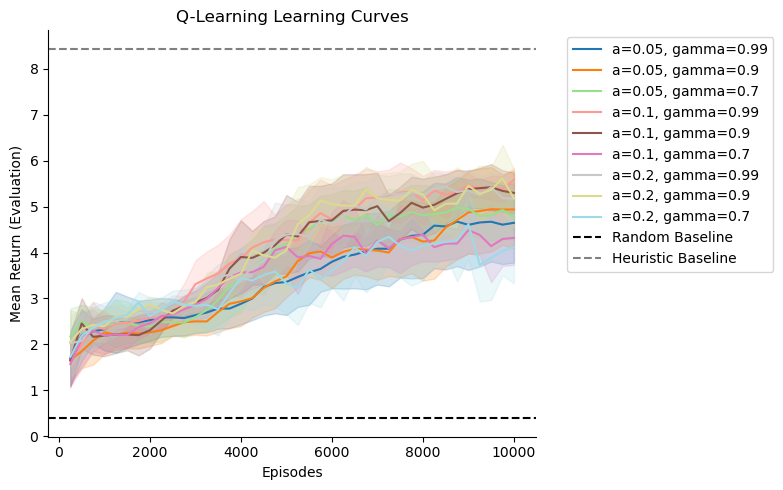

In [63]:
import matplotlib.cm as cm

num_curves = len(hyperparams_grid)
colors = cm.tab20(np.linspace(0, 1, num_curves))

# Plot of learning curves
x_axis = np.arange(250, train_episodes + 1, 250)

fig, ax = plt.subplots(figsize=(8, 5))

for config_idx, config in enumerate(hyperparams_grid):
    returns = results[config_idx]
    mean_returns = np.mean(returns, axis=0)
    std_returns = np.std(returns, axis=0)
    
    label = f"a={config['alpha']}, gamma={config['gamma']}"
 
    curve_color = colors[config_idx]
    
    ax.plot(x_axis, mean_returns, label=label, color=curve_color)
    ax.fill_between(x_axis, mean_returns - std_returns, mean_returns + std_returns, 
                    color=curve_color, alpha=0.2)

# Baselines (heuristic and random)
ax.axhline(y=0.39, color='black', linestyle='--', label='Random Baseline')
ax.axhline(y=8.44, color='gray', linestyle='--', label='Heuristic Baseline')

ax.set_xlabel('Episodes')
ax.set_ylabel('Mean Return (Evaluation)')
ax.set_title('Q-Learning Learning Curves')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

The parameters yielding the best results are $\alpha = 0.1$ and $\gamma = 0.99$. Let's focus on the learning curve of the agent associated with these parameters.

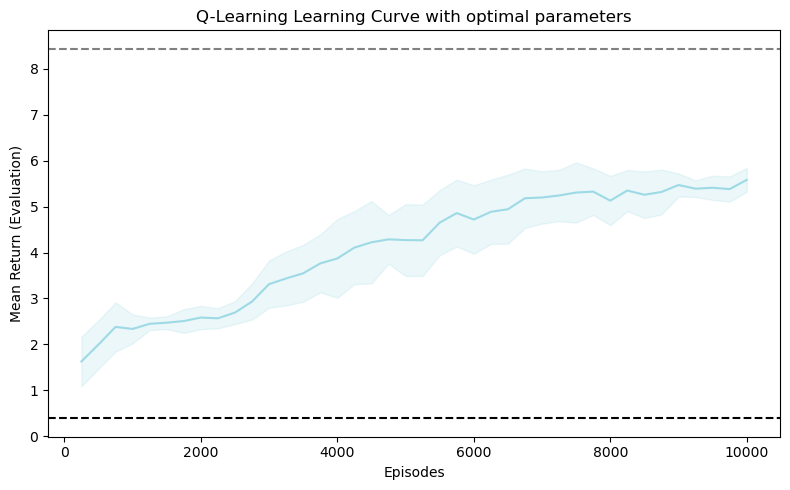

In [72]:
import matplotlib.cm as cm

num_curves = len(hyperparams_grid)
colors = cm.tab20(np.linspace(0, 1, num_curves))

# Plot of learning curves
x_axis = np.arange(250, train_episodes + 1, 250)

fig, ax = plt.subplots(figsize=(8, 5))


returns = results[3]
mean_returns = np.mean(returns, axis=0)
std_returns = np.std(returns, axis=0)



ax.plot(x_axis, mean_returns, label=label, color=curve_color)
ax.fill_between(x_axis, mean_returns - std_returns, mean_returns + std_returns, 
                color=curve_color, alpha=0.2)

# Baselines (heuristic and random)
ax.axhline(y=0.39, color='black', linestyle='--', label='Random Baseline')
ax.axhline(y=8.44, color='gray', linestyle='--', label='Heuristic Baseline')

ax.set_xlabel('Episodes')
ax.set_ylabel('Mean Return (Evaluation)')
ax.set_title('Q-Learning Learning Curve with optimal parameters')

# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---

## Part 3: A Deep RL Method [10 marks]

Implement a reinforcement learning algorithm that uses neural networks for function approximation.

### Requirements

- Choose an appropriate algorithm
- Design a neural network architecture suited to the observation space
- Apply techniques to stabilize training as needed

### Questions to Address

1. **State representation**: Do you use the raw observation or a transformed representation? How does this choice influence your network architecture?

Since neural networks are able to process boolean tensors directly, I chose to use the raw observation instead of the transformed representation as in the previous part. This allows the model to keep all the information of the observation and state without loosing potentially useful information as with the transformed representation.

As a result, we need to use a network architecture that is able to process the observations in their raw form and not flattened in a 1D vector: so we can't use a classical MLP. I will use a CNN instead as it is able to process directly the boolean tensors. 

2. **Algorithm description**: What algorithm did you implement? Describe the loss function and update procedure.

I implemented a Deep Q-Network algorithm. 

The loss function used to train the DQN is the L2 loss (MSE) between the predicted Q-values and target Q-values: for a given sample $i$ of states, actions, rewards, next state $(x_i,a_i,r_i,x_i')$, the loss associated with this sample is: 
$$ L_i = (Q_i - y_i)^2$$
where $Q_i = Q_{\theta_k}(x_i,a_i)$ is our current prediction of the Q-value at episode $k$ and $y_i = r_i + \gamma \max_{a'} Q_{w}(x_i',a')$ is the target Q-value. 

The update procedure of the DQN algorithm is the following: 
- collection: at each episode $k$, the agent interacts with the environment according to an $\epsilon-$greedy policy to collect data which is stored in the replay buffer. 
- at the end of episode $k$, we sample a mini batch $(x'_{i_j},a_{i_j},r_{i_j},x_{i_j}')_{j=1}^{128}$ containing 128 datapoints from the replay buffer. 
- we update the weights of the main network using backprop:
$$ \theta_{k+1} = \arg\min_{\theta} \sum_{j=1}^{128} (Q_{\theta}(x_{i_j},a_{i_j})-y_{i_j})^2 $$
- every 1000 episodes, the weights of the target network are updated.


3. **Architecture**: What neural network architecture did you use? Justify your design choices.

I used a CNN: as mentioned above, we need to use a CNN to process raw observations. The layers are the following: 
- a Conv2D layer with ReLu activation for spatial extraction,
- a dense layer with 64 networks with Relu activation,
- a linear output layer with 3 neurons corresponding to the 3 possible actions for regression on $y_i$. The output layer has no activation function because this is a regression task, not a classification task (in this case we could use a softmax function for instance). 

I did not use Max Pooling because the grid is very small (10x10) so it is not relevant to use it in this setting. 

4. **Learning curves**: Plot training progress. Compare different hyperparameter choices, if applicable.

The training curve is given below. 

5. **Comparison**: How does the deep RL method compare to your classical RL method from Part 2? Consider sample efficiency, final performance, and training stability.

When both the Q-learning and DQN model are trained over 10000 iterations, DQN strongly overperforms Q-learning in terms of average reward (moving average of rewards at 9.5 for DQN vs average reward at 5 for Q-learning). It even beats the heuristic baseline. DQN converges faster than Q-learning because DQN already has a moving average reward of 5 after 4000 episodes while Q-learning needs 10000 episodes to reach an average reward of 5. 

However, Q-learning has a better sample efficiency than DQN. Indeed, DQN has to maintain a replay buffer made of 100 000 raw observations, while Q-learning do not need to store any of the past observations and not use the raw observations but only a representation with a much smaller size. 

Besides, in terms of training stability, DQN is much more instable: from one episode to the other, the average reward obtained by DQN can increase or decrease a lot, even sometimes drop to zero very abruptly as shown by the learning curve. For instance, at episode 9800, the moving average reward (over the 50 past episodes) yielded by DQN is of 7.1 and it drops to 5.82 at episode 9900. On the contrary, the learning curve of Q-learning is very smooth and increases consistently: Q-learning has a great training stability.



The code below is the class for the DQN agent.

In [34]:
import torch.nn as nn
import torch.optim as optim
from collections import deque


#class for the CNN architecture in the DQN
class DQN_CNN(nn.Module):
    def __init__(self, in_channels, num_actions):
        super(DQN_CNN, self).__init__()
        # input : (Batch, 4, 10, 10) required by pytorch
        self.conv_layer = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, stride=1),
            nn.ReLU()
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(16 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, num_actions)
            # output : (Batch, num_actions)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.reshape(x.size(0), -1) 
        x = self.fc_layer(x)
        return x

# replay buffer class
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.stack(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.stack(next_states),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

# DQN agent class
class DQNAgent:
    def __init__(self, num_actions, device):
        self.num_actions = num_actions
        self.device = device
        
        # hyperparameters are set arbitrarly and on what i did in the previous questions
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.1
        self.epsilon_decay = 0.995
        self.batch_size = 128
        self.target_update_freq = 1000
        
        self.memory = ReplayBuffer(capacity=100000)
        
        # Initialisation 
        self.policy_net = DQN_CNN(in_channels=4, num_actions=num_actions).to(self.device)
        self.target_net = DQN_CNN(in_channels=4, num_actions=num_actions).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval() 
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-4)
       
        self.loss_fn = nn.MSELoss() 

        self.steps_done = 0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(self.num_actions)
        else:
            with torch.no_grad():
              
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                q_values = self.policy_net(state_tensor)
                return q_values.argmax(dim=1).item()

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        # computation of Q(s, a)
        q_values = self.policy_net(states).gather(1, actions)

        # Computation of max Q(s', a') with the target 
        with torch.no_grad():
            max_next_q_values = self.target_net(next_states).max(1)[0].unsqueeze(1)
        
        expected_q_values = rewards + (self.gamma * max_next_q_values * (1 - dones))

        loss = self.loss_fn(q_values, expected_q_values)
        
        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping to avoid gradient explosion
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

The code below is the training loop function for the DQN agent.

In [137]:
def format_state(state):
    # we need to change the format of observations (H, W, C) to what PyTorch expects ie (C, H, W)
    state = np.array(state, dtype=np.float32)
    return np.transpose(state, (2, 0, 1))

def train_dqn(num_episodes=500,seed = 42):

    set_seed(seed)
    
    env = gym.make("MinAtar/Breakout-v1")
    env.reset(seed=seed)      
    env.action_space.seed(seed)

    num_actions = env.action_space.n 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    agent = DQNAgent(num_actions, device)
    
    rewards_history = []
    
    for episode in range(num_episodes):
        state, _ = env.reset() 
        state = format_state(state)
        
        total_reward = 0
        done = False
        
        while not done:
            action = agent.select_action(state)
            
    
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            next_state = format_state(next_state)
            
            agent.memory.push(state, action, reward, next_state, done)
            agent.optimize_model()
            
            state = next_state
            total_reward += reward
            agent.steps_done += 1
            
            if agent.steps_done % agent.target_update_freq == 0:
                agent.update_target_network()
                
        agent.update_epsilon()
        rewards_history.append(total_reward)
    
        if episode % 100 == 0:
            print(f"episode {episode}, average reward: {np.mean(rewards_history[-50:])}")
        
    return rewards_history, agent
    

We can now train the DQN agent and plot the resulting learning curve.

In [36]:
rewards_history, dqn_agent = train_dqn(num_episodes=10000)

episode 0, average reward: 0.0
episode 100, average reward: 0.38
episode 200, average reward: 0.34
episode 300, average reward: 0.58
episode 400, average reward: 1.06
episode 500, average reward: 0.92
episode 600, average reward: 1.78
episode 700, average reward: 2.2
episode 800, average reward: 1.9
episode 900, average reward: 2.42
episode 1000, average reward: 2.42
episode 1100, average reward: 2.36
episode 1200, average reward: 2.24
episode 1300, average reward: 2.5
episode 1400, average reward: 2.9
episode 1500, average reward: 3.14
episode 1600, average reward: 2.96
episode 1700, average reward: 3.4
episode 1800, average reward: 3.96
episode 1900, average reward: 3.36
episode 2000, average reward: 4.04
episode 2100, average reward: 4.3
episode 2200, average reward: 4.04
episode 2300, average reward: 4.42
episode 2400, average reward: 4.14
episode 2500, average reward: 4.24
episode 2600, average reward: 4.48
episode 2700, average reward: 4.58
episode 2800, average reward: 4.16
epis

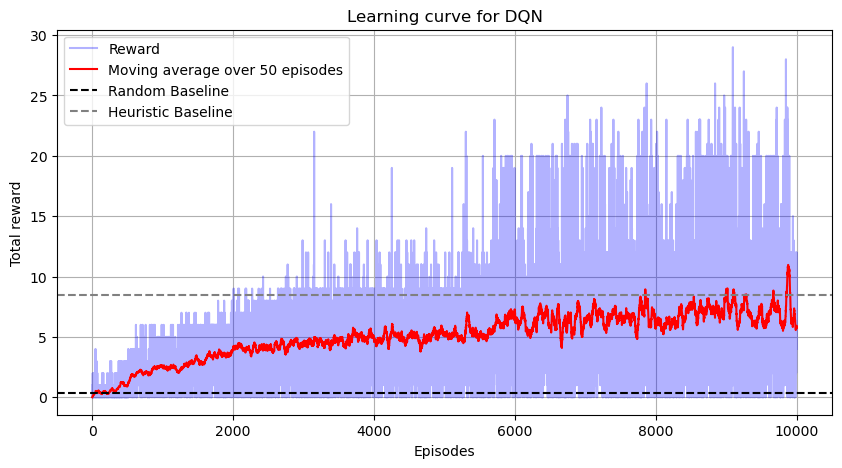

In [37]:

#plots of learning curve 
plt.figure(figsize=(10, 5))
plt.plot(rewards_history[:10000], alpha=0.3, color='blue', label='Reward')

# moving average on the past 50 episodes
moving_avg = np.convolve(rewards_history, np.ones(50)/50)
plt.plot(np.arange(0, len(rewards_history[:10000])), moving_avg[:10000], color='red', label='Moving average over 50 episodes')

# Baselines (heuristic and random)
plt.axhline(y=0.39, color='black', linestyle='--', label='Random Baseline')
plt.axhline(y=8.44, color='gray', linestyle='--', label='Heuristic Baseline')

plt.title('Learning curve for DQN')
plt.xlabel('Episodes')
plt.ylabel('Total reward')
plt.legend()
plt.grid(True)
plt.show()

---

## Part 4: Policy Interpretation [8 marks]

Analyze the behavior of your trained agents.

### Questions to Address

1. **Qualitative behavior**: Report a video of your trained agent playing. Describe its strategy in words. Does it behave similarly to the heuristic, or has it learned a different approach?

The videos of the trained Q-learning agent and DQN agent are given below. 
- The Q-learning strategy is relatively similar to the heuristic strategy, in the sense that it follows the movements by moving the paddle in the same direction as the ball: this is what we would expect from any strategy that works. However, we can see that the Q-learning agent moves the paddle less often than the heuristic strategy: the Q-learning strategy is therefore more static and more "economical" in terms of paddle movements. For example, at the end of the episode on the video, the agent does not even try to catch the ball, and the paddle remains static as the ball moves away from it, resulting in the end of the game. The heuristic strategy would still have tried to follow the ball even if it could not catch it.
- The DQN strategy is quite different from the heuristic strategy. The paddle does not follow the ball's movements as closely as it does with the heuristic strategy. In particular, the DQN strategy seems to avoid going to the corners of the grid and stays in the middle of the grid as much as possible, which makes sense because staying too far from the center of the grid can make the ball uncatchable. This phenomenon can be observed even when the ball hits one of the corners of the grid: the heuristic strategy would have moved towards the corner of the grid, but the DQN strategy remains in the center. Another difference is that the DQN strategy oscillate a lot and moves the paddle a lot from left to right and right to left, even when the ball is heading in a specific direction. Perhaps this is associated with noise and the model should have been trained over more episodes to achieve smoother and less erratic racket movements.

The functions below allow to produce reproductible videos. 

In [46]:

def make_dqn_policy(agent):
    def policy_fn(observation, num_actions):

        state_formatted = format_state(observation)

        old_eps = agent.epsilon
        agent.epsilon = 0.0 
        
        action = agent.select_action(state_formatted)
        
        agent.epsilon = old_eps 
      
        return action % num_actions 
    return policy_fn

def make_qlearning_policy(q_agent):

    def policy_fn(observation, num_actions):
        state_tuple = extract_state(observation) 
        return np.argmax(q_agent.q_table[state_tuple])
    
    return policy_fn

**Video for the Q-learning agent:** 

To produce a video of the Q-learning trained agent, we first need to retrain the Q-learning for the best values of $\alpha$ and $\gamma$ that we identified in part 2. 

In [47]:
env_train = gym.make("MinAtar/Breakout-v1")
env_eval = gym.make("MinAtar/Breakout-v1")
n_actions = env_train.action_space.n

config = {"alpha": 0.1, "gamma": 0.99, "eps_decay": 0.9997}

train_episodes = 10000

eval_steps = train_episodes // 250

np.random.seed(42)
env_train.action_space.seed(42)
env_eval.action_space.seed(42)

q_agent = QLearningAgent(
    n_actions=n_actions, 
    alpha=config["alpha"], 
    gamma=config["gamma"], 
    eps_start=1.0, 
    eps_end=0.1, 
    eps_decay=config["eps_decay"]
)

eval_idx = 0
#loop to train the model over 2000 episodes
for episode in range(train_episodes):
    current_seed = 42 if episode == 0 else None
    obs, _ = env_train.reset(seed=current_seed) 
    state = extract_state(obs)
    terminated = False
    truncated = False
    
    #play the policy, update Q values, 
    while not (terminated or truncated):
        action = q_agent.act(state)
        obs, reward, terminated, truncated, _ = env_train.step(action)
        next_state = extract_state(obs)
        q_agent.update(state, action, reward, next_state, terminated)
        state = next_state
    
    #update of exploration policy 
    q_agent.decay_epsilon()


    if (episode + 1) %  250 == 0:

        q_policy = make_q_policy(q_agent)
        
        rewards_array, steps_array = evaluate_policy(env_eval, q_policy, num_episodes = 25)
        
        eval_idx += 1

In [48]:
env_visual = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array", disable_env_checker=True)
env_visual.reset()

q_eval_policy = make_qlearning_policy(q_agent) 

frames_q, reward_q, steps_q = run_episode_with_frames(env_visual, q_eval_policy)
print(f"Episode: Reward = {reward_q}, Steps = {steps_q}")
anim_q = animate_episode(frames_q, interval=100)
HTML(anim_q.to_jshtml())

Episode: Reward = 6, Steps = 70


**Video for the DQN agent**

In [39]:
env_visual = gym.make("MinAtar/Breakout-v1", render_mode="rgb_array", disable_env_checker=True)
env_visual.reset()


dqn_eval_policy = make_dqn_policy(dqn_agent) 

frames_dqn, reward_dqn, steps_dqn = run_episode_with_frames(env_visual, dqn_eval_policy,seed = 123)
print(f"DQN Episode: Reward = {reward_dqn}, Steps = {steps_dqn}")

anim_dqn = animate_episode(frames_dqn, interval=100)
HTML(anim_dqn.to_jshtml())

DQN Episode: Reward = 10, Steps = 118


2. **State-action analysis**: For your best policy, visualize what actions it selects in different states.

A visualisation of the actions chosen by the DQN algorithm for different states is given below. We can notice that in most cases the Q-values are consistent associated with each action are consistent with the state: for instance, if the paddle is just below the ball, the Q-value associated with action "don't move" is higher than the Q-values associated with "go left" and "go right".

In the plot below, the ball is in red and the ball trail is in green.

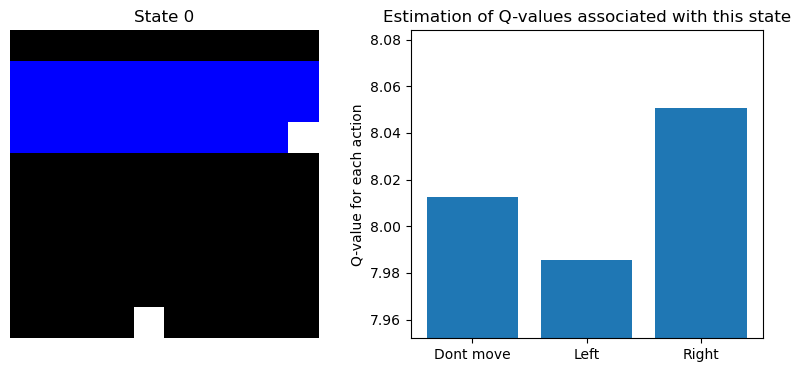

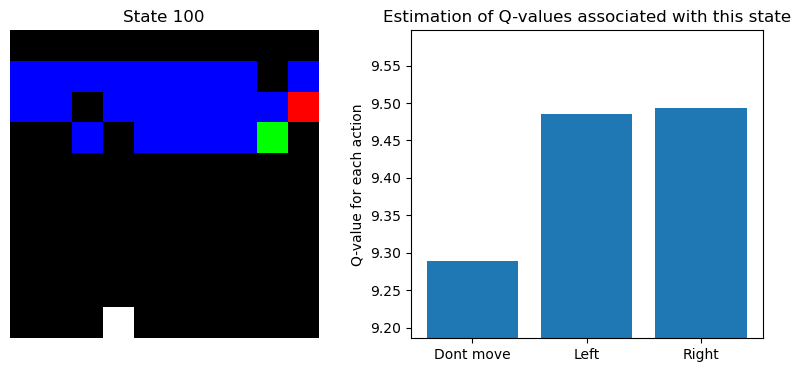

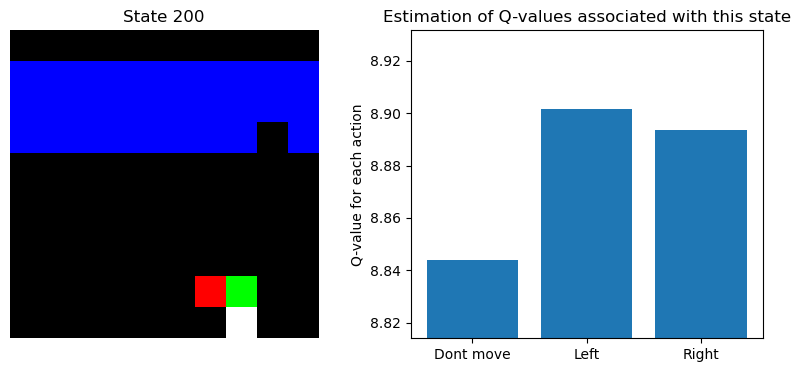

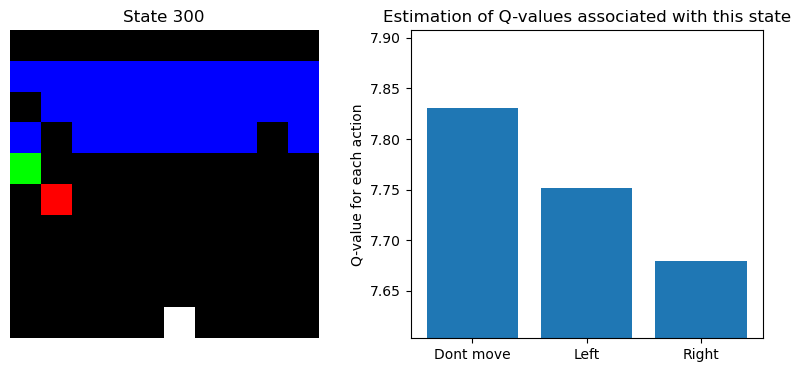

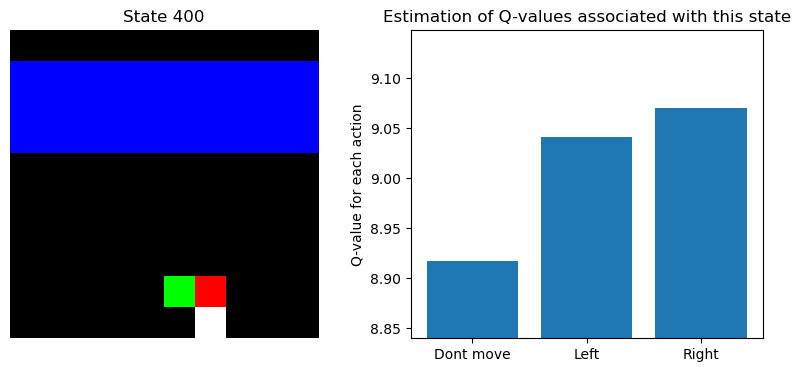

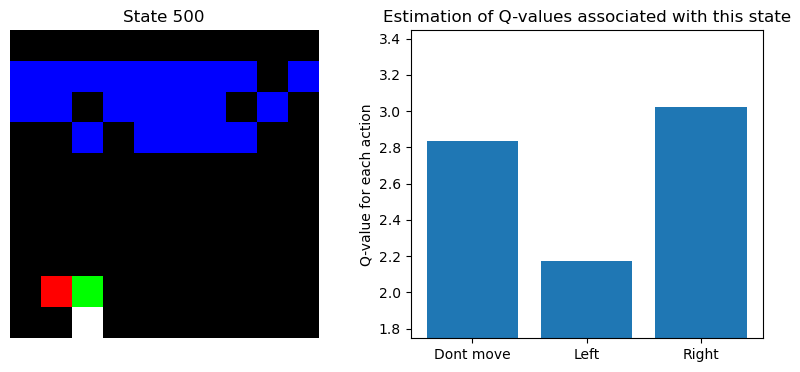

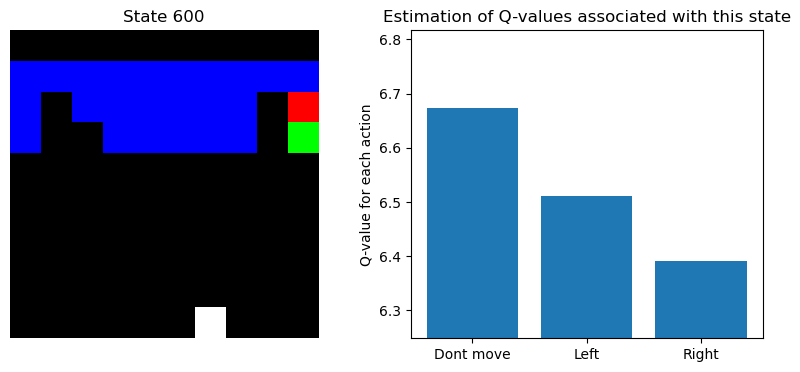

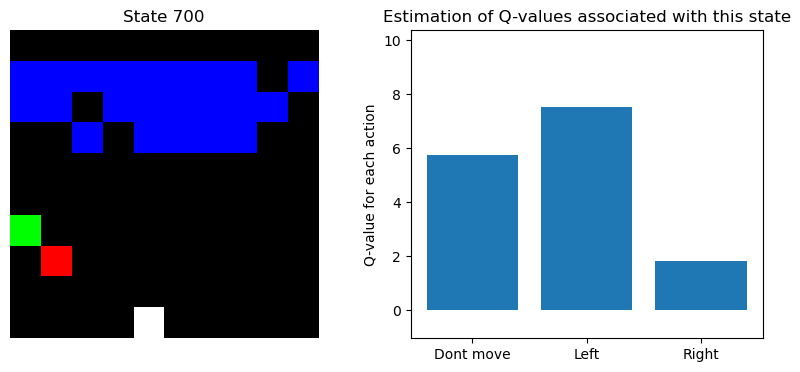

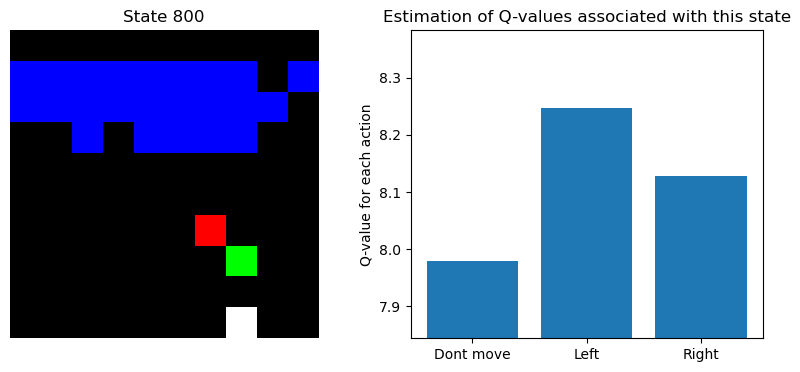

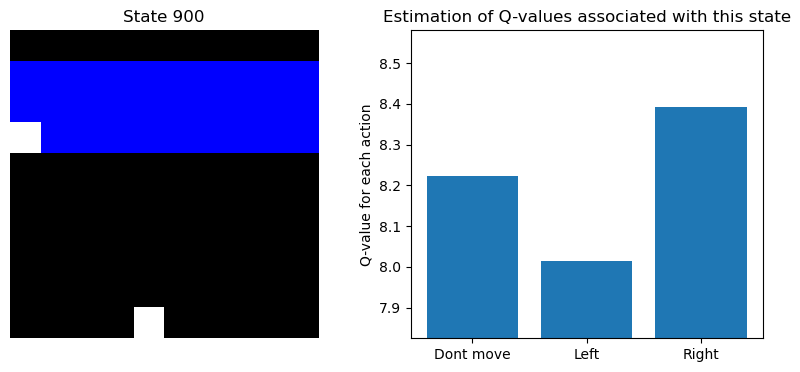

In [72]:
#function to collect states to visualize Q values associated with these states
def collect_sample_states(env, policy_fn, n_states=1000):
    states = []
    obs, _ = env.reset()
    for _ in range(n_states):
        states.append(obs)
        action = policy_fn(obs, env.action_space.n)
        obs, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            obs, _ = env.reset()
    return states

#function to add color to the plots produced below
def obs_to_rgb(obs):
    #paddle = white, ball = red, ball trail = green, brick = blue
    colors = np.array([[255, 255, 255], [255, 0, 0], [0, 255, 0], [0, 0, 255]])
    return np.clip(obs @ colors, 0, 255).astype(np.uint8)


sample_states = collect_sample_states(env_visual, dqn_eval_policy)

for s in np.arange(0,1000,100):
    state = sample_states[s]
    state_fmt = format_state(state)
    state_tensor = torch.FloatTensor(state_fmt).unsqueeze(0).to(dqn_agent.device)

    with torch.no_grad():
        q_values = dqn_agent.policy_net(state_tensor).cpu().numpy()[0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # plot of state
    ax1.imshow(obs_to_rgb(state))
    ax1.set_title(f"State {s}")
    ax1.axis('off')

    # plot of Q value per action 
    actions = ['Dont move', 'Left', 'Right']
    ax2.bar(actions, q_values)
    q_min = q_values.min()
    q_max = q_values.max()
    margin = (q_max - q_min) * 0.5 + 1e-3  
    ax2.set_ylim(q_min - margin, q_max + margin)

# for i, (action, qv) in enumerate(zip(actions, q_values)):
#     ax2.text(i, qv + margin * 0.1, f'{qv:.4f}', ha='center', fontsize=10)
    ax2.set_title("Estimation of Q-values associated with this state")
    ax2.set_ylabel("Q-value for each action")
    plt.show()

3. **Failure cases**: Identify situations where the policy makes poor decisions. What do these cases have in common?

The code below plots the last 5 iterations before the end of a game and the associated q-values for 4 games. 
- The first failure is caused by the actions at t-2 and t-1 before the end of part t: the ball moves to the left, but at t-2, the paddle does not move because the Q-value associated with “don't move” is slightly higher than that associated with “left.” Similarly, at t-1, the paddle moves to the right (which is absurd because it should move to the left) because the Q-value associated with “left” is tiny. These errors are probably caused by the fact that these state-action pairs have not been explored enough, because the model has not been trained on enough data. 
- The second failure is caused by the action at t-2: the policy chooses not to move when the ball is going to the right and it would be necessary to go to the right. This is probably due to a lack of training, as the Q-value associated with “don't move” is 5.95, while the Q-value associated with “right” is 5.29. 
- The third failure is caused by the fact that the paddle moves to the right and/or does not move at t-3, t-2, and t-1, when it should move to the left because the ball is moving to the left. This is due to the fact that the Q-values have weird negative values: it is therefore clearly a lack of training and the policy has not seen these state-action pairs enough, which explains the negative Q-values.

These poor decisions all seem to be caused by the fact that the Q-values take weird values, either negative or very close for the different actions, because the policy has not sufficiently explored the considered pairs of state-actions, so the network overfits the data that it has seen so far and outputs weird values.



In [90]:
#the function below collects states and q values right before the end of a game 
def collect_failure_states(env, agent, n_failures=20, steps_before=4,seed=42):
    env.reset(seed=seed)
    env.action_space.seed(seed)
    failures = []  # list of (state, q_values, action chosen)
    episode_count = 0
    
    while len(failures) < n_failures:
        obs, _ = env.reset(seed=seed + episode_count)
        episode_count += 1
        episode_buffer = []  
        done = False
        
        while not done:
            state_fmt = format_state(obs)
            state_tensor = torch.FloatTensor(state_fmt).unsqueeze(0).to(agent.device)
            
            with torch.no_grad():
                q_vals = agent.policy_net(state_tensor).cpu().numpy()[0]
            
            action = np.argmax(q_vals)  
            
            episode_buffer.append({
                'state': obs.copy(),
                'q_values': q_vals.copy(),
                'action': action
            })
            
            # keeps only the last 5 steps before loosing the game
            if len(episode_buffer) > steps_before:
                episode_buffer.pop(0)
            
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        
        if terminated:
            failures.append(episode_buffer.copy())
    
    return failures

Failure number 1


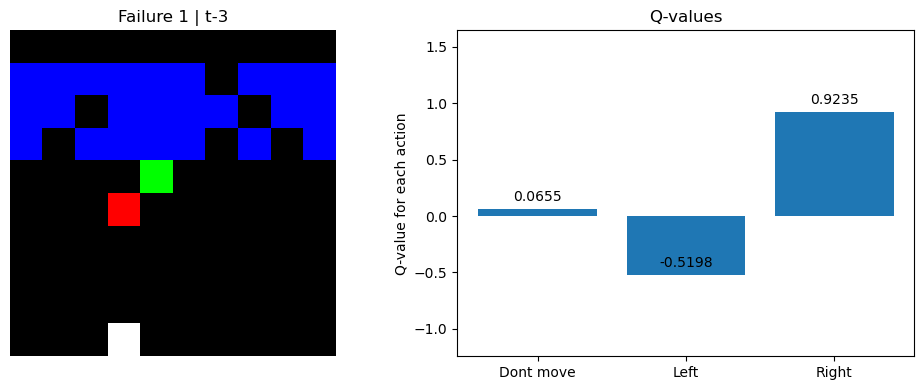

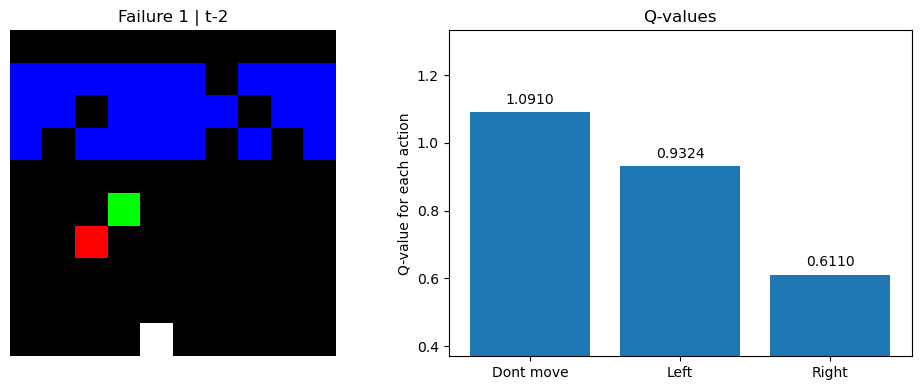

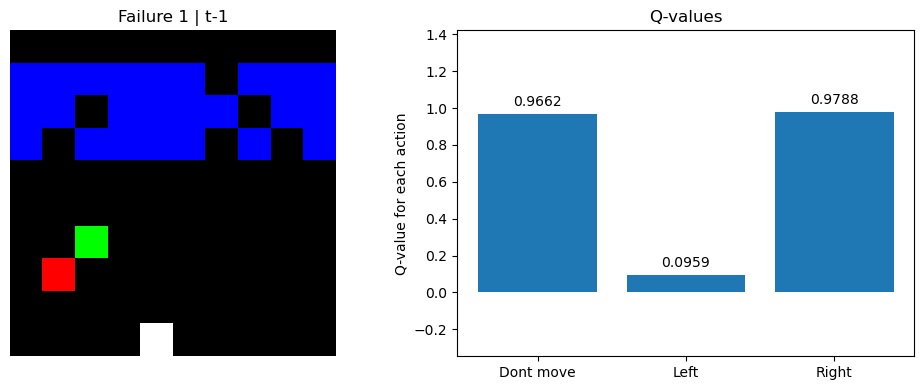

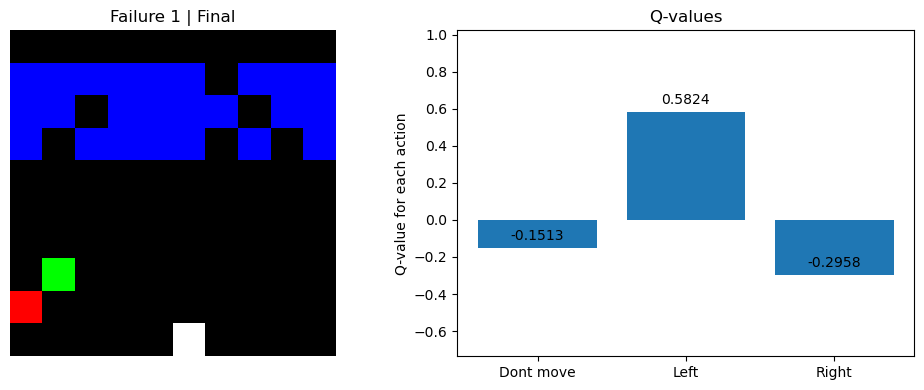

Failure number 2


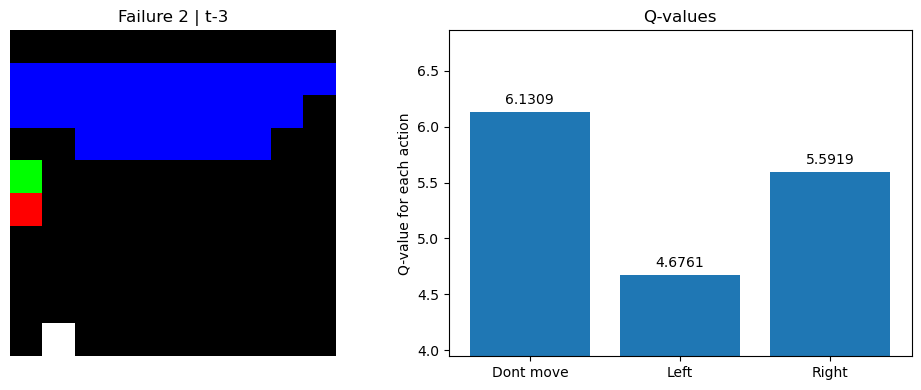

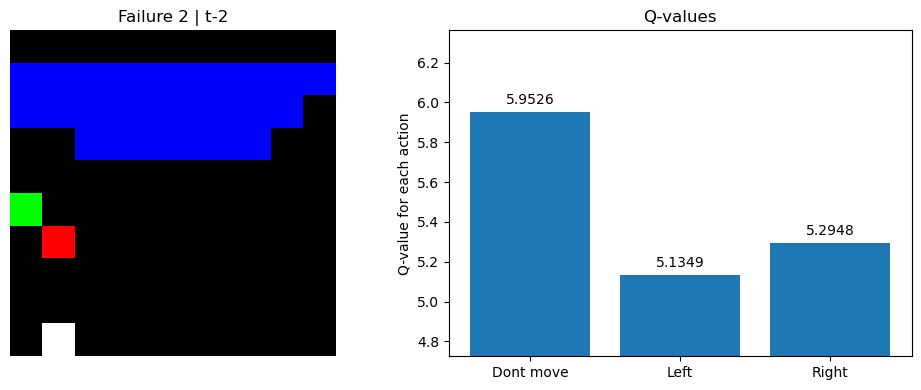

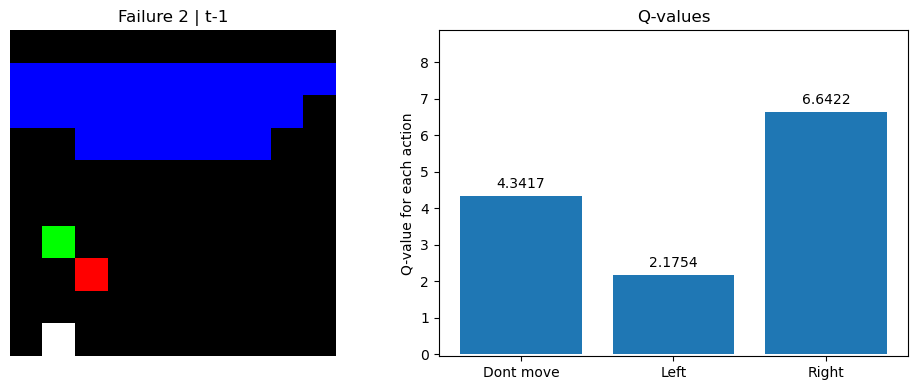

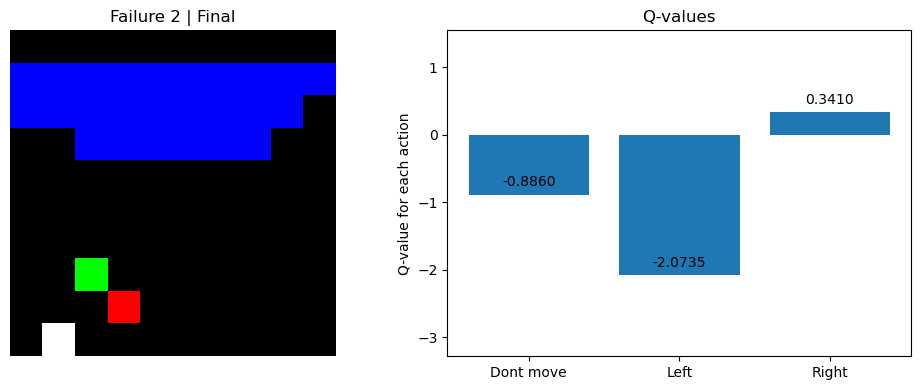

Failure number 3


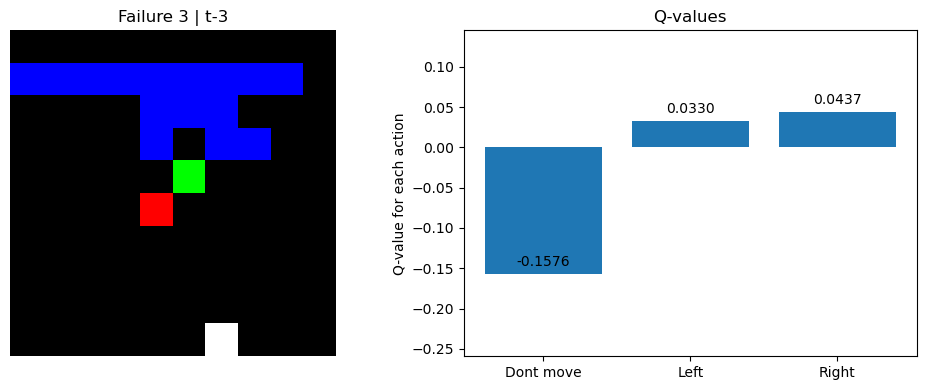

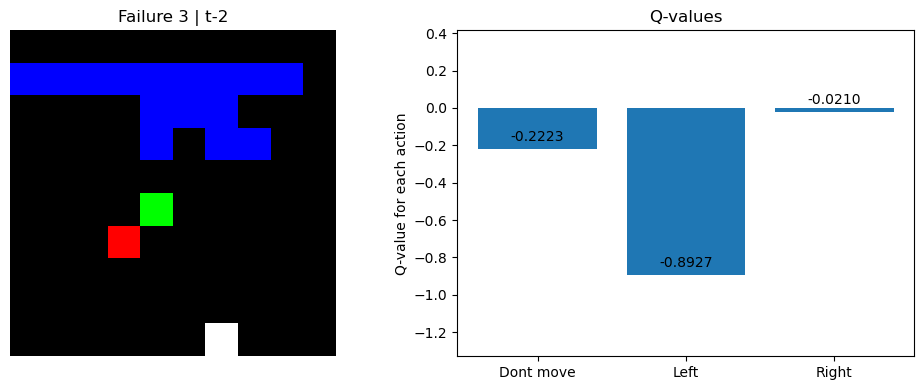

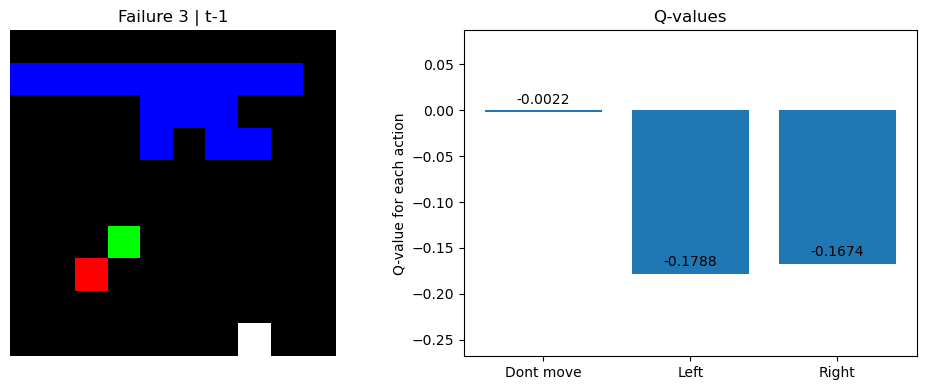

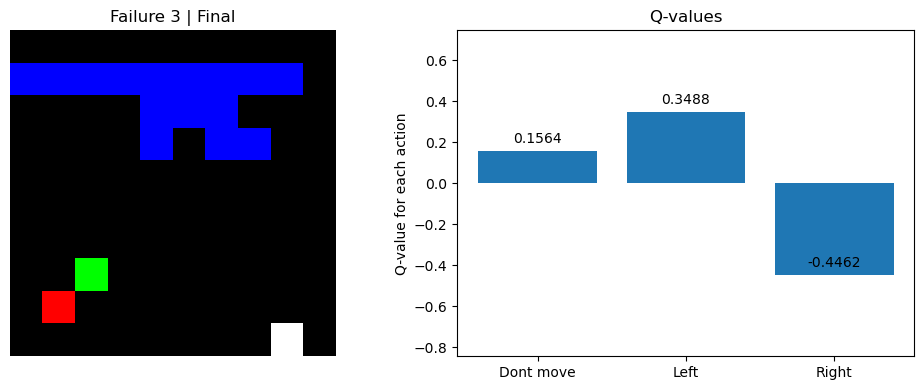

Failure number 4


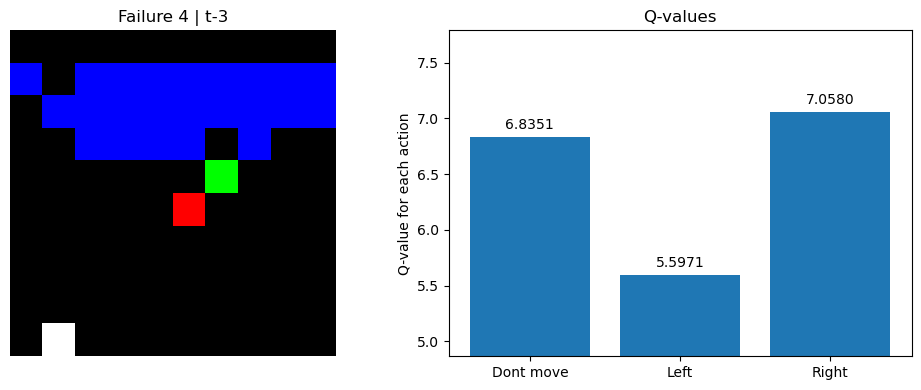

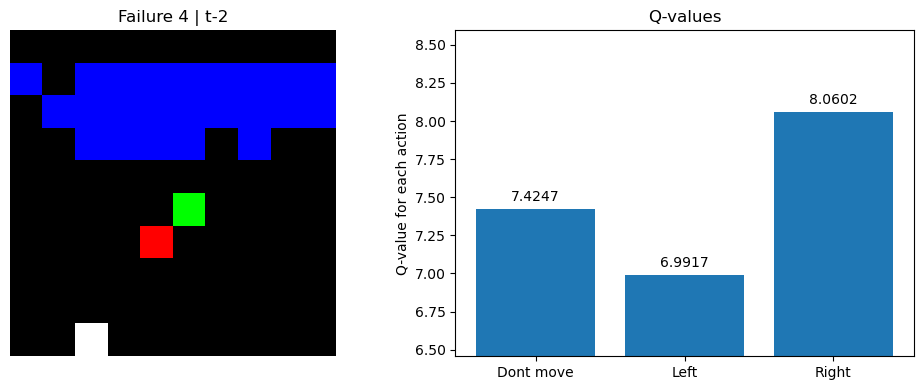

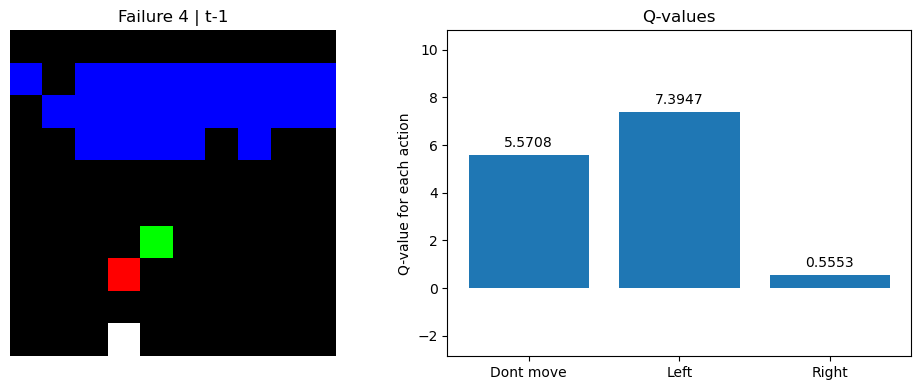

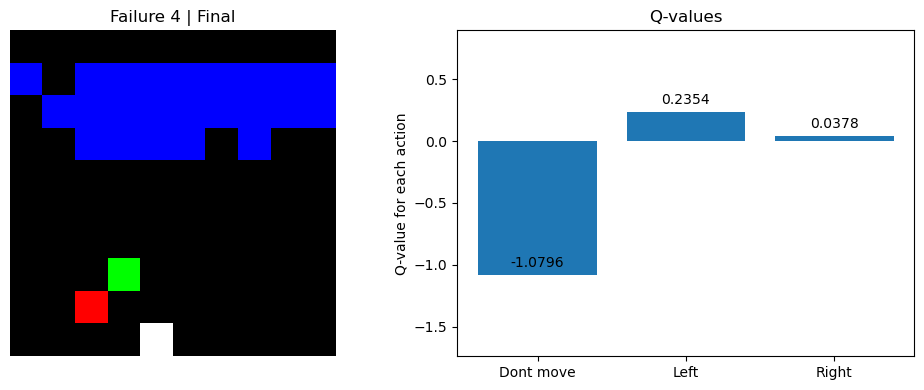

Failure number 5


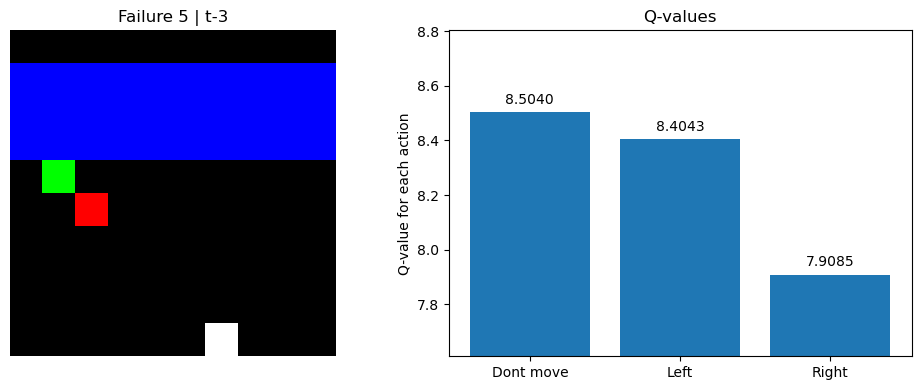

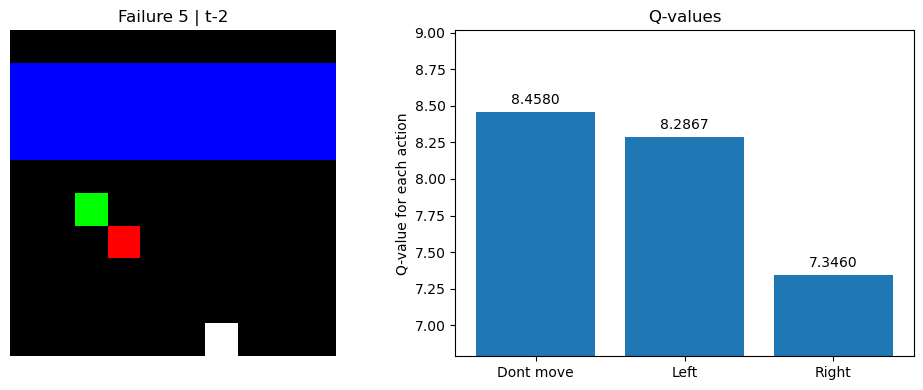

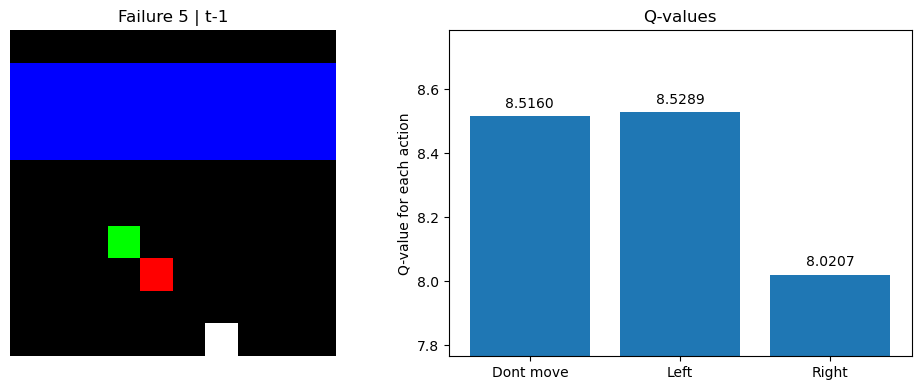

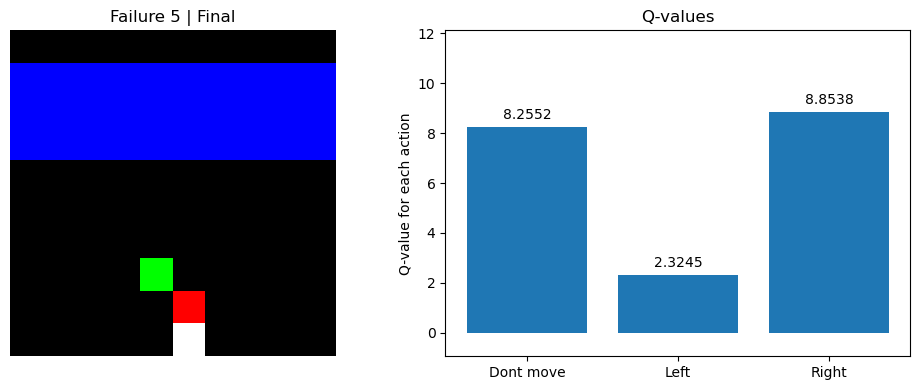

In [91]:
failures = collect_failure_states(env_visual, dqn_agent, n_failures=8)
failures = failures[3:8]
for failure_idx, sequence in enumerate(failures):
    print(f"Failure number {failure_idx + 1}")
    
    for step_idx, step in enumerate(sequence):
        state = step['state']
        q_values = step['q_values']
        action_chosen = step['action']

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

        # plot of state
        ax1.imshow(obs_to_rgb(state))
        label = "Final" if step_idx == len(sequence) - 1 else f"t-{len(sequence) - step_idx - 1}"
        ax1.set_title(f"Failure {failure_idx + 1} | {label}")
        ax1.axis('off')

        # plot of Q values per action
        actions = ['Dont move', 'Left', 'Right']
        # colors_bar = ['red' if i == action_chosen else 'steelblue' for i in range(len(actions))]
        ax2.bar(actions, q_values)
        
        q_min = q_values.min()
        q_max = q_values.max()
        margin = (q_max - q_min) * 0.5 + 1e-3
        ax2.set_ylim(q_min - margin, q_max + margin)

        for i, (action, qv) in enumerate(zip(actions, q_values)):
            ax2.text(i, qv + margin * 0.1, f'{qv:.4f}', ha='center', fontsize=10)

        ax2.set_title("Q-values")
        ax2.set_ylabel("Q-value for each action")
        plt.tight_layout()
        plt.show()

4. **Comparison across methods**: Do your classical and deep RL methods learn similar or different strategies? If not, why ?

The DQN and Q-learning strategies are quite different:

The Q-learning strategy is quite static, it keeps the paddle at the center of the grid most of the time and it does not move much the paddle to the ends of the grid. This is probably because the policy has not visited enough states where the ball is on the ends of the grids so some parts of the Q-table are not accurate at all. 

On the contrary, the DQN strategy moves the paddle from the left to the right a lot, oscillates a lot, so that the paddle movements are quite erratic. This is because the DQN learns a generalization function with the CNN: so the agent will react to states that it has never seen but in an erratic way. In particular, in some cases, the paddle oscillates very abruptly between left and right, because the agent hesitates and the Q-values for "left" and "right" are very close, which explains such oscillations.

---

## Part 5: Improving Performance [4 marks]

Investigate techniques to improve your agents' performance and training stability.

### Requirements

Choose **at least two** of the following directions:

- **Ablation study**: Remove or modify components of your algorithm and measure the impact.
- **Variance reduction**: Implement and compare techniques to reduce gradient variance.
- **Regularization**: Experiment with regularization techniques and analyze their effects.
- **Hyperparameter sensitivity**: Systematically vary hyperparameters and report their effects.
- **Exploration strategies**: Compare different exploration methods. [At least 2]

### Instructions for the report

For each investigation:
- State your hypothesis before running experiments
- Present results with appropriate visualizations
- Discuss whether results matched your expectations and explain any surprises
- Discuss the limitations and their probable solutions of your proposed approach.

## I- Ablation study 

### A) Hypothesis 

I'll remove the following components of the DQN: the target network, and then reduce the replay buffer. I'll also add to train my DQN with a Huber loss instead of a MSE loss. 

**Removing the target network:** 
My hypothesis is that removing the target network will make the training curve much more unstable and increase a lot the variance of the rewards per episode series. This behaviour would be caused by the fact that without target network, the target Q-value and our prediction of Q-value will be very correlated: this should create a moving target, resulting in big oscillations in the weights of the network when we update them after episodes. 

**Reducing the size of the replay buffer from 100000 to 1000:** 
My hypothesis is that reducing the size of the replay buffer will also make the training curve more unstable, because datapoints are more likely to be dependent in a small replay buffer compared to a large replay buffer. The iid assumption is then violated which will make the optimization of the network more unstable. 

**Train the DQN with a Huber loss:** 
My hypothesis is that training the DQN with a Huber loss rather than a MSE could stabilize the training curve. Indeed, the Huber loss behaves like a MSE when the error term is small, and like a L1 loss when the error term is large: so if error terms are very large, it avoids that the weights of the neural network change a lot from one episode to the other. So we can expect a faster and more stable early training: later in training, when the network has converged, MSE and Huber loss should behave similarly.



### B) Visualisation

Below is the code that allows to visualise my experiments:

In [101]:
class DQNAgent_modified:
    def __init__(self, num_actions, device,
                 gamma=0.99,
                 epsilon_decay=0.995,
                 epsilon_min=0.1,
                 batch_size=128,
                 target_update_freq=1000,
                 lr=1e-4,
                 replay_capacity=100000,
                 # ablation 
                 use_target_network=True,
                 use_replay_buffer=True,
                 use_huber_loss=False
             ):
        
        self.num_actions = num_actions
        self.device = device
        self.gamma = gamma
        self.epsilon = 1.0
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        
        # ablation flags
        self.use_target_network = use_target_network
        self.use_replay_buffer = use_replay_buffer
        self.use_huber_loss = use_huber_loss
        
        self.memory = ReplayBuffer(capacity=replay_capacity if use_replay_buffer else 1000)
        
        self.policy_net = DQN_CNN(in_channels=4, num_actions=num_actions).to(self.device)
        self.target_net = DQN_CNN(in_channels=4, num_actions=num_actions).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        if self.use_huber_loss == True:
            self.loss_fn = nn.SmoothL1Loss()
        else:
            self.loss_fn = nn.MSELoss()
        self.steps_done = 0

    def optimize_model(self):
        if len(self.memory) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        q_values = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            if self.use_target_network:
                max_next_q_values = self.target_net(next_states).max(1)[0].unsqueeze(1)
            else:
                # ablation : uses policy network instead of target network
                max_next_q_values = self.policy_net(next_states).max(1)[0].unsqueeze(1)

        expected_q_values = rewards + (self.gamma * max_next_q_values * (1 - dones))

        loss = self.loss_fn(q_values, expected_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        
        self.optimizer.step()

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(self.num_actions)
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
                q_values = self.policy_net(state_tensor)
                return q_values.argmax(dim=1).item()

    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [ ]:
def train_dqn_modif(num_episodes=2000, seed=42, **agent_kwargs):
    set_seed(seed)
    env = gym.make("MinAtar/Breakout-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)

    num_actions = env.action_space.n
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    agent = DQNAgent_modified(num_actions, device, **agent_kwargs)

    rewards_history = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        state = format_state(state)
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = format_state(next_state)

            agent.memory.push(state, action, reward, next_state, done)
            agent.optimize_model()

            state = next_state
            total_reward += reward
            agent.steps_done += 1

            if agent.steps_done % agent.target_update_freq == 0:
                agent.update_target_network()

        agent.update_epsilon()
        rewards_history.append(total_reward)

    return rewards_history

In [ ]:
ablation_experiments = {
    "Baseline (MSE + no target)":          {"use_target_network": False, "use_huber_loss": False},
    "MSE + target network":                {"use_target_network": True,  "use_huber_loss": False},
    "Huber + no target network":           {"use_target_network": False, "use_huber_loss": True},
    "Huber + target network":              {"use_target_network": True,  "use_huber_loss": True},
    "Small replay buffer (1000)":          {"use_target_network": True,  "use_huber_loss": False, "replay_capacity": 1000},
}

ablation_results = {}
for name, kwargs in ablation_experiments.items():
    print(f"Training: {name}")
    ablation_results[name] = train_dqn_modif(num_episodes=2000, seed=42,**kwargs)

Training: Baseline (MSE + no target)
Training: MSE + target network
Training: Huber + no target network
Training: Huber + target network
Training: Small replay buffer (1000)


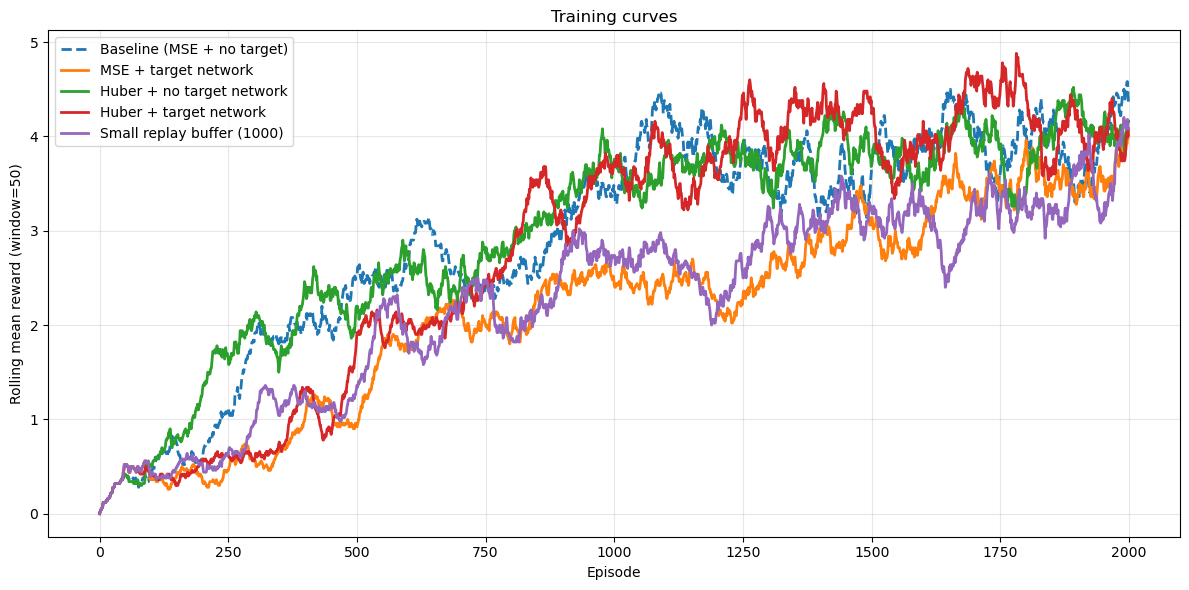

In [ ]:

plt.figure(figsize=(12, 6))

for name, rewards in ablation_results.items():

    episodes = np.arange(len(rewards))
    linestyle = '--' if 'baseline' in name.lower() else '-'
    plt.plot(episodes, np.convolve(rewards, np.ones(50)/50)[:2000], label=name, linestyle=linestyle, linewidth=2)

plt.xlabel("Episode")
plt.ylabel(f"Rolling mean reward (window={50})")
plt.title("Training curves (rolling mean reward over 50 past episodes)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### C) Results vs hypothesis 

From the learning curves above we see that:
- removing the target network (blue vs orange curve) does not change anything in terms of learning stability: this is not aligned with my hypothesis. Actually, the DQN agent with target networks learns more slowly than the one without target network, and both learning curves are very unstable. This could be because 2000 episodes is not enough to see the positive impact of the target network. 
- training the network with a Huber loss increases stability of learning, especially in the early phase of training, which is aligned with my hypothesis (see green and red curve vs other curves). However I excepted that the DQN with Huber loss would have a steeper learning curve at the beginning of training, which is not necessarly true.
- reducing the size of the replay buffer increases a bit the instability of learning (purple curve), even though all learning curves are overall quite unstable and volatile. 

Overall, my assumptions on the Huber loss and on the replay buffer are partially confirmed by the experiments, and my assumption on the target network is invalidated. However, all the learning curve have roughly the same shape and order of magnitude, and grow roughly at the same rate: we do not observe a collapse of performance when we remove a specific component of the DQN model. So the experiments are not a very strong empirical proof of my asumptions. 


### D) Limitations of my approach

The main reason why the experiments are not a very strong empirical proof of my assumptions could be that 2000 episodes of training is not enough to see the effects of removing components of the network. I also did experiments on only one seed because I needed to reduce a bit the computational time of the experiments. If I had more time ahead, I would run the experiments on at least 10000 episodes and on 5 seeds to have a better idea of the impact of removing the replay buffer or target network and adding the Huber loss. 

## II- Hyperparameters sensitivity

In this experiment I increase or decrease the following hyperparameters of the DQN model:
- the learning rate, 
- the discount factor $\gamma$,
- the $\epsilon_{decay}$ parameter, which control the rate at which the $\epsilon$ parameter of our $\epsilon-$greedy exploration policy decreases. 

### A) Hypothesis

My assumptions are that: 
- increasing the learning rate can accelerate learning and yield a higher average reward at the end of 2000 episodes, however it will also probably increase the variance of the learning curve because the weights of the network may change more after each episode, because of the larger learning rate. On the contrary, decreasing the learning rate may slow down learning and reduce the steepness of the learning curve, but it should also stabilize it because the weights of the network will change more slowly; 
- decreasing the discount factor can reduce the performance of the agent which will struggle to link future rewards happening at time $t$ with past actions at time $t-1,t-2,\dots$, because $\gamma^t$ will be very close to zero. On the contrary, increasing it could increase the average reward. 
- decreasing the $\epsilon_{decay}$ parameter could slow down learning because we stop exploring too early. Increasing $\epsilon_{decay}$ too high could also slow down learning because we keep exploring too much even after a long training. 



### B) Visualisation 

In [ ]:
hyperparam_experiments = {
    "gamma=0.90": {"gamma": 0.90},
    "gamma=0.95": {"gamma": 0.95},
    "gamma=0.99 (baseline)": {"gamma": 0.99},
    
    "lr=1e-3":            {"lr": 1e-3},
    "lr=1e-4 (baseline)": {"lr": 1e-4},
    "lr=1e-5":            {"lr": 1e-5},
    
    "epsilon_decay=0.999": {"epsilon_decay": 0.999},
    "epsilon_decay=0.995 (baseline)": {"epsilon_decay": 0.995},
    "epsilon_decay=0.990": {"epsilon_decay": 0.990},
}

hyperparam_results = {}
for name, kwargs in hyperparam_experiments.items():
    print(f"Training: {name}")
    hyperparam_results[name] = train_dqn_modif(num_episodes=2000, seed=42, **kwargs)

Training: gamma=0.90
Training: gamma=0.95
Training: gamma=0.99 (baseline)
Training: lr=1e-3
Training: lr=1e-4 (baseline)
Training: lr=1e-5
Training: epsilon_decay=0.999
Training: epsilon_decay=0.995 (baseline)
Training: epsilon_decay=0.990


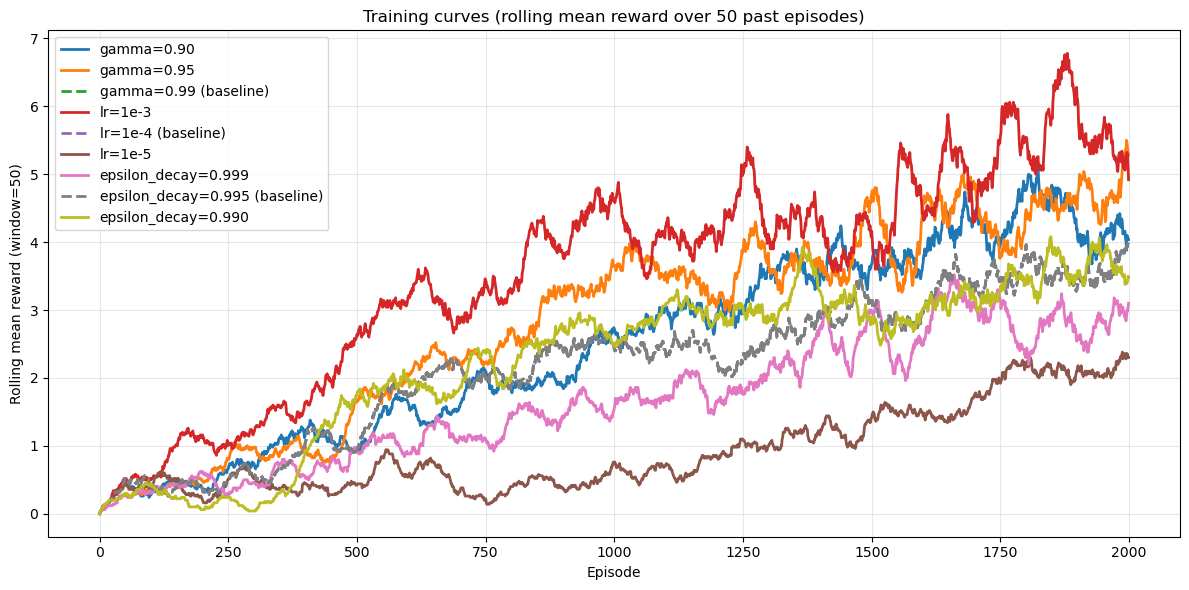

In [118]:

plt.figure(figsize=(12, 6))

for name, rewards in hyperparam_results.items():
  
    episodes = np.arange(len(rewards))
    linestyle = '--' if 'baseline' in name.lower() else '-'
    plt.plot(episodes, np.convolve(rewards, np.ones(50)/50)[:2000], label=name, linestyle=linestyle, linewidth=2)

plt.xlabel("Episode")
plt.ylabel(f"Rolling mean reward (window={50})")
plt.title("Training curves (rolling mean reward over 50 past episodes)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### C) Hypothesis vs results of experiments

From the learning curves above, we see that: 
- increasing the learning rate indeed accelerates learning and yields to overall higher rewards, while also increasing the variability of rewards (red curve vs grey curve). On the contrary, decreasing the learning rate slows down learning and reduces variability of rewards (brown curve vs grey curve). This is aligned with my assumption. 
- decreasing the discount factor $\gamma$ increases the average reward (orange and blue curve vs grey curve). This is not aligned with my assumption, which shows that the baseline $\gamma = 0.99$ is too high and should be set lower, since we have better results for $\gamma = 0.95$ or $\gamma = 0.9$. Moreover, decreasing the value of $\gamma$
 also increases the variability of the learning curve, which is not something I excepted either.
 - decreasing the $\epsilon_{decay}$ parameter does not change much things, while increasing it slightly reduces the average reward (pink, grey and light green curves). This is partially aligned with my assumptions as I excepted that decreasing $\epsilon_decay$ would decrease the reward too. This is probably because the model is not so sensitive to the value of this parameter.

### D) Limitations of my approach

Once again, the results that are not aligned with my assumptions and with the theory may be caused by the fact that we train the models on 2000 episodes only and only on one seed. If I had more time, I would reproduce the experiments on 10000 episodes and with 5 seeds. If I had more computational power, I would also try other values of $\epsilon_{decay}$ as the values chosen are maybe not different enough to properly assess the sensitivity of the model to this hyperparameter.

---

## Part 6: Generalization to Other Environments [5 marks]

Test whether your methods transfer to other MinAtar games: Asterix, Freeway, Seaquest, and Space Invaders.

### Questions to Address

1. **Direct transfer**: Apply your best Breakout agent (without retraining) to another game. Does it perform better than random? Why or why not?

Asterix is the only game that has 4 channels (like breakout) so I will apply the Breakout DQN agent to this game specifically. From the code below, we can see that the Breakout agent performs as poorly as the random policy (average reward for random = 0.48, average reward for DQN = 0.55) with similar standard deviations. This is not very surprising because our Breakout agent was trained specifically to play to Breakout, which is a very different game from Asterix in which the agent has to distinguish between ennemies and objects to collect. So the states/observations of the Asterix game are very different from that of Breakout, and the actions chosen by the Breakout agent in these states are not relevant at all for the Asterix game. 

In the plot below, the top of the blue bar represents the mean of rewards and the black bars represent the std of rewards on 1000 episodes.

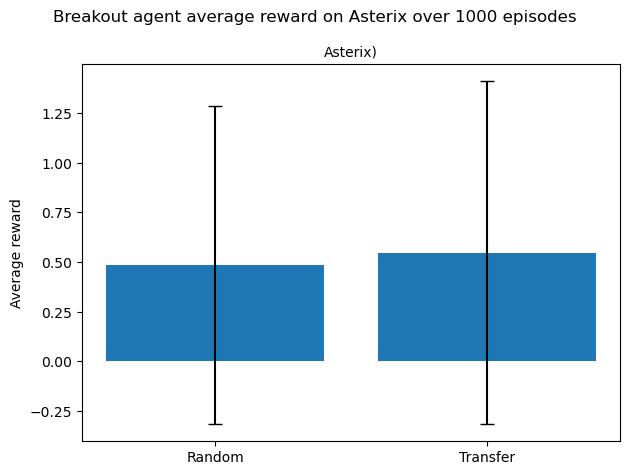

In [133]:
breakout_policy = make_dqn_policy(dqn_agent)

results = {}

for game in ["Asterix"]:
    
    set_seed(42)
    env = gym.make(f"MinAtar/{game}-v1")
    env.reset(seed=42)
    env.action_space.seed(42)

    transfer_rewards, _ = evaluate_policy(env, breakout_policy, num_episodes=1000)
    random_rewards,   _ = evaluate_policy(env, random_policy,   num_episodes=1000)
    env.close()

    results[game] = {
        "transfer": transfer_rewards,
        "random":   random_rewards}

fig, ax = plt.subplots()


r      = results[game]
means  = [r["random"].mean(),   r["transfer"].mean()]
stds   = [r["random"].std(),    r["transfer"].std()]


ax.bar(["Random", "Transfer"], means, yerr=stds, capsize=5)
ax.set_title(f"{game})", fontsize=10)
ax.set_ylabel("Average reward")

fig.suptitle("Breakout agent average reward on Asterix over 1000 episodes")
plt.tight_layout()
plt.show()

In [134]:
means

[np.float64(0.484), np.float64(0.548)]

2. **Retraining**: Train your deep RL method on at least one other MinAtar game. Does it achieve similar performance relative to the random baseline? If performance differs, explain why.

I've retrained a DQN network on Asterix. I've done only 5000 episodes of training for computation time reasons. 

The method strongly overperforms the random baseline, the moving average of rewards after 5000 episodes is at 9.3. The performance differs because the DQN model has been trained on 5000 episodes while the random baseline do not exploits at all the observed data and just plays actions at random. 

In [140]:

def train_dqn_on_asterix(num_episodes=500,seed = 42):

    set_seed(seed)
    
    env = gym.make("MinAtar/Asterix")
    env.reset(seed=seed)      
    env.action_space.seed(seed)

    num_actions = env.action_space.n 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    agent = DQNAgent(num_actions, device)
    
    rewards_history = []
    
    for episode in range(num_episodes):
        state, _ = env.reset() 
        state = format_state(state)
        
        total_reward = 0
        done = False
        
        while not done:
            action = agent.select_action(state)
            
    
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            next_state = format_state(next_state)
            
            agent.memory.push(state, action, reward, next_state, done)
            agent.optimize_model()
            
            state = next_state
            total_reward += reward
            agent.steps_done += 1
            
            if agent.steps_done % agent.target_update_freq == 0:
                agent.update_target_network()
                
        agent.update_epsilon()
        rewards_history.append(total_reward)
    
        if episode % 100 == 0:
            print(f"episode {episode}, average reward: {np.mean(rewards_history[-50:])}")
        
    return rewards_history, agent
    

In [141]:
rewards_history_asterix, dqn_agent_asterix = train_dqn_on_asterix(num_episodes=5000)

c:\Users\jean-\anaconda3\Lib\site-packages\gymnasium\envs\registration.py:520: UserWarning: WARN: Using the latest versioned environment `MinAtar/Asterix-v1` instead of the unversioned environment `MinAtar/Asterix`.
  logger.warn(


episode 0, average reward: 0.0
episode 100, average reward: 0.38
episode 200, average reward: 0.38
episode 300, average reward: 0.64
episode 400, average reward: 0.88
episode 500, average reward: 0.82
episode 600, average reward: 0.58
episode 700, average reward: 0.88
episode 800, average reward: 1.24
episode 900, average reward: 1.08
episode 1000, average reward: 1.36
episode 1100, average reward: 1.06
episode 1200, average reward: 1.22
episode 1300, average reward: 1.74
episode 1400, average reward: 2.24
episode 1500, average reward: 2.64
episode 1600, average reward: 2.7
episode 1700, average reward: 3.18
episode 1800, average reward: 2.06
episode 1900, average reward: 3.18
episode 2000, average reward: 3.1
episode 2100, average reward: 2.08
episode 2200, average reward: 2.36
episode 2300, average reward: 2.9
episode 2400, average reward: 2.52
episode 2500, average reward: 2.4
episode 2600, average reward: 3.3
episode 2700, average reward: 3.28
episode 2800, average reward: 4.4
epis

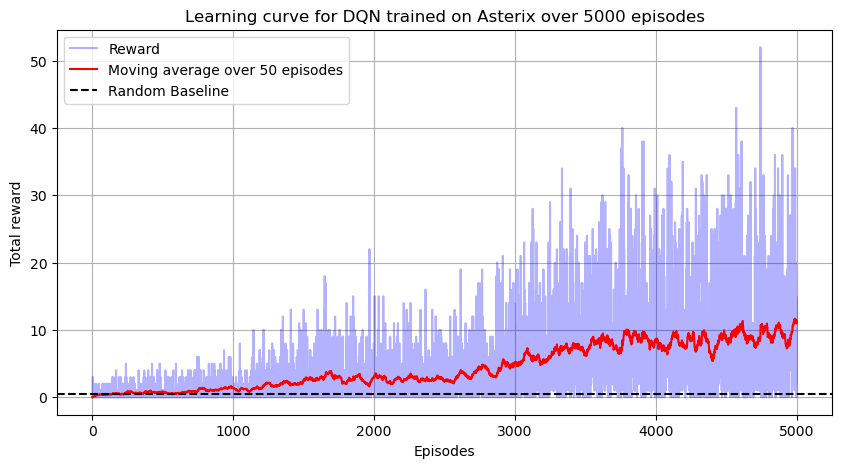

In [145]:

#plots of learning curve 
plt.figure(figsize=(10, 5))
plt.plot(rewards_history_asterix[:5000], alpha=0.3, color='blue', label='Reward')

# moving average on the past 50 episodes
moving_avg = np.convolve(rewards_history_asterix, np.ones(50)/50)
plt.plot(np.arange(0, len(rewards_history_asterix[:5000])), moving_avg[:5000], color='red', label='Moving average over 50 episodes')

# random baseline with average mean = 0.48 
plt.axhline(y=0.48, color='black', linestyle='--', label='Random Baseline')

plt.title('Learning curve for DQN trained on Asterix over 5000 episodes')
plt.xlabel('Episodes')
plt.ylabel('Total reward')
plt.legend()
plt.grid(True)
plt.show()

3. **Architecture/hyperparameter transfer**: Can you use the same configuration across games, or do different games require different configurations?

We can use the same CNN architecture to train DQN agents for all games, because all MinAtar games are represented on a 10x10 grid with several channels. 

However, I think that the hyperparameters should be different and adapted to each game because the rewards are not received at the same frequency in all games. For some games, the discount factor $\gamma$ should be smaller or larger: for instance, for Freeway, we receive a reward only after having fully crossed the road, so $\gamma$ should be closer to 1 than in Breakout. 

Similarly, the $\epsilon_{decay}$ parameter of the $\epsilon-$ greedy policy should be adapted to each game because of the lower or higher frequency of rewards for each game. On Freeway, we want to set $\epsilon_{decay}$ very close to 1 so that the agent keeps exploring for a long time, otherwise the agent will stop exploring before having seen any reward, because it is difficult to obtain rewards by playing purely randomly at the beginning of the game. 

4. **Game difficulty**: Which games are easier or harder to learn? Relate this to environment properties.

Intuitively, a game with more states and actions will be more difficult to learn because it will be more difficult to predict correctly the Q-values associated with the different state-action pairs; Moreover, a game with a reward structure that is sparse and with a delay between actions and rewards will be more difficult to learn, because it is more complicated for the agent to learn the impact of past actions at time $t-1,t-2,...$ on the rewards at time $t$. Besides, the more the rules of the game are complex, the more difficult it will be to learn.

Hence, Breakout and Asterix are easier to learn because there are respectively 3/5 actions and 4 channels for both these games, so the size of the space-action space is limited, and the reward structure is not too sparse compared to other games. On the contrary, Freeway, Seaquest and Space Invaders are more difficult to learn because there are respectively 3/6/4 actions and 7/10/6 channels. In particular, Freeway will be especially complex to learn because of the sparse reward structure. Seaquest will be more difficult to learn too of the complexity of the rules: the agent needs to fire bullets at other submarines and fishes while maintaining a sufficient supply of oxygen. 

---

## Summary

Conclude your notebook with a brief summary of:

- Your main findings across all parts
- What worked well and what did not
- What you would try next if you had more time

Make one paragraph answering these three points for each part of the assignment.

### Summary for part 2: 

The Q-learning agent works decently as it yields an average reward of 6 after 10000 episodes of training and when choosing the best hyperparameters. However, it still does not beat the heuristic baseline, because it does not explore enough some state-action pairs, especially when the ball and the paddle are at the ends of the grid. This results in a policy which keeps the paddle static, at the center of the grid most of the time, and which struggles with states where the ball is at the extremities of the grid. If I had more time, I would try to implement an optimistic initialization that set all values of the Q-table at 5 or 6 at the beginning of training instead of at 0. This could encourage the agent to explore more states-action pairs that it has not much visited. I would also change the epsilon greedy policy to keep exploring more, for instance by forcing $\epsilon$ not to decrease below 0.1, so that the agent keeps exploring 10% of the time, even after many episodes of training.


### Summary for part 3: 

The DQN agent trained directly on the raw observations (with target network and replay buffer) works way better than the Q-learning because it yields an average reward of 9.5 after 10000 episodes of training, converging to the performance of the heuristic baseline: this demonstrates the relevance of predicting Q-values associated with raw observations/states-actions using a convolutional neural network. However, this approach has downsides, because the training curve is very unstable and the reward can drop from 10 to 0 from one episode to the other. If I had more time, I would have retrained the network with a slightly higher learning rate and a Huber loss, over a larger number of episodes (eg 100 000) to see how large the average reward can become. 

### Summary for part 4: 

When visualising a game played by the Q-learning policy, we see that the paddle is quite static, that it remains at the center of the grid and that it avoids to go on the ends of the grid, probably because the agent has not explored enough states in which both the ball and the paddle are on the ends of the grid. On the contrary, the DQN policy moves the paddle a lot, and the movements of the paddle are sometimes a bit erratic, because the agent "hesitates" when it faces states that it has not seen before. When looking at ends of episodes, we see that the errors made by the DQN agent (which result in the ball touching the bottom of the grid) are caused by the fact that Q-values are weird and sometimes even take negative values. This is because the agent has not seen enough similar states, which results in negative values. If I had more time, it would be interesting to study the errors made by the DQN agent trained on 100 000 episodes, to see if errors are still caused by Q-values taking absurd values. 

### Summary for part 5: 

When doing the ablation study, we see that increasing the size of the replay buffer (from 1000 to 100 000) and replacing the MSE loss with a Huber loss when training the DQN yields to a more stable learning curve. However, removing the target network do not have much impact on the performance of the algorithm. This is probably the DQN agents were trained only on 2000 iterations and on one seed: we should train them on several seeds and on a larger number of episodes to really assess the impact of the target network. We also see that increasing the learning rate and decreasing a bit the value of the discount factor increases the average reward, while changing the $\epsilon_{decay}$ parameter do not impact much the learning curve. If I had more time, it would be interesting to try a wider grid of hyperparameters and several seeds to produce plots of the final reward as a function of the hyperparameter: this sensitivity analyisis would allow us to choose the best possible hyperparameters. 

### Summary for part 6:

Using the Breakout DQN agent to play to Asterix yields terrible results that are as bad as those of the random policy. However, when retraining the same DQN model on Asterix, we get good results and a satisfying average reward even after only 5000 episodes of training. We can reuse the same architecture but it is relevant to adapt the hyperparameters (especially the discount factor and $\epsilon_{decay}-$) to the structure of the game. If I had more time, I would train other DQN agents on each of the game by judiciously choosing their hyperparameters beforehand. 


